In [1]:
"""
Customer Segmentation Analysis - Retail Transaction Data
=========================================================

This notebook provides a complete workflow for customer segmentation
based on transactional data from TOKEN, VENTE, ARTICLE, and MAGASIN tables.

Project Goals:
1. Identify distinct customer segments based on purchasing behavior
2. Characterize each segment's habits and preferences
3. Discover sales opportunities (upselling, cross-selling, optimization)
4. Provide actionable business insights
"""

"\nCustomer Segmentation Analysis - Retail Transaction Data\n=========================================================\n\nThis notebook provides a complete workflow for customer segmentation\nbased on transactional data from TOKEN, VENTE, ARTICLE, and MAGASIN tables.\n\nProject Goals:\n1. Identify distinct customer segments based on purchasing behavior\n2. Characterize each segment's habits and preferences\n3. Discover sales opportunities (upselling, cross-selling, optimization)\n4. Provide actionable business insights\n"

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [3]:
# For clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score

# For association rules
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [4]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:


# Create session
print("\n[STEP 1.1] Loading CSV files...")

try:
    df_token = pd.read_csv('TOKEN.csv')
    df_vente = pd.read_csv('VENTE.csv')
    df_article = pd.read_csv('ARTICLE.csv')
    df_magasin = pd.read_csv('MAGASIN.csv')

    
    for df in [df_token, df_vente, df_article, df_magasin]:
        df.columns = [c.strip() for c in df.columns]
    
    print(f"✓ TOKEN loaded: {df_token.shape}")
    print(f"✓ VENTE loaded: {df_vente.shape}")
    print(f"✓ ARTICLE loaded: {df_article.shape}")
    print(f"✓ MAGASIN loaded: {df_magasin.shape}")
    
except FileNotFoundError as e:
    print(f"ERROR: {e}")
    print("Please update the file paths in the code to match your CSV locations.")

# Load tables
# df_vente = session.table("POC_ECOLE.SALES.VENTE").to_pandas()
# df_token = session.table("POC_ECOLE.SALES.TOKEN").to_pandas()
# df_article = session.table("POC_ECOLE.SALES.ARTICLE").to_pandas()
# df_magasin = session.table("POC_ECOLE.SALES.MAGASIN").to_pandas()

# Clean column names
for df in [df_token, df_vente, df_article, df_magasin]:
    df.columns = [c.strip() for c in df.columns]

print(f"✓ TOKEN loaded: {df_token.shape}")
print(f"✓ VENTE loaded: {df_vente.shape}")
print(f"✓ ARTICLE loaded: {df_article.shape}")
print(f"✓ MAGASIN loaded: {df_magasin.shape}")


[STEP 1.1] Loading CSV files...
✓ TOKEN loaded: (174007, 2)
✓ VENTE loaded: (32879372, 11)
✓ ARTICLE loaded: (2312, 7)
✓ MAGASIN loaded: (66, 9)
✓ TOKEN loaded: (174007, 2)
✓ VENTE loaded: (32879372, 11)
✓ ARTICLE loaded: (2312, 7)
✓ MAGASIN loaded: (66, 9)


In [6]:
df_magasin.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_MAG_TIERS                  66 non-null     int64  
 1   ID_LIEU_DE_VENTE              66 non-null     int64  
 2   LB_DESIGNATION_LIEU_DE_VENTE  66 non-null     str    
 3   LB_ADRESSE                    66 non-null     str    
 4   CD_POSTAL                     66 non-null     int64  
 5   LB_VILLE                      66 non-null     str    
 6   LATITUDE                      66 non-null     float64
 7   LONGITUDE                     66 non-null     float64
 8   DT_OUVERTURE                  66 non-null     str    
dtypes: float64(2), int64(3), str(4)
memory usage: 4.8 KB


In [7]:
print("\n[STEP 1.2] Initial Data Exploration")

def explore_dataframe(df, name):
    print(f"\n{name} Table:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"\n  First few rows:")
    print(df.head(3))
    return df.info()

# Explore each table
for df, name in [(df_token, 'TOKEN'), (df_vente, 'VENTE'),
                  (df_article, 'ARTICLE'), (df_magasin, 'MAGASIN')]:
    explore_dataframe(df, name)


[STEP 1.2] Initial Data Exploration

TOKEN Table:
  Shape: (174007, 2)
  Columns: ['NO_TOKEN_CB', 'CD_TICKET_UNIQUE']
  Memory usage: 20.08 MB
  Missing values:
Series([], dtype: int64)

  First few rows:
                                         NO_TOKEN_CB     CD_TICKET_UNIQUE
0  A33FB7919EEAB875A8AF4493286211B29F49B0746939EF...  4949207601061614291
1  2755B58F8A00BA3FA60E9E69A1951194F048FDF5FB0C2C...  4945949002201926787
2  7B6704A84131A41FF8F2CB121FD2517FE65F52B714B4C4...  4964269402201934474
<class 'pandas.DataFrame'>
RangeIndex: 174007 entries, 0 to 174006
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   NO_TOKEN_CB       174007 non-null  str  
 1   CD_TICKET_UNIQUE  174007 non-null  int64
dtypes: int64(1), str(1)
memory usage: 2.7 MB

VENTE Table:
  Shape: (32879372, 11)
  Columns: ['CD_TICKET_UNIQUE', 'DT_VENTE', 'TS_VENTE', 'ID_MAG_TIERS', 'ID_ARTICLE', 'MT_TTC_NET', 'TX_TVA', 'QT_UVC', 'QT_POIDS',

In [8]:
df_vente.info()

<class 'pandas.DataFrame'>
RangeIndex: 32879372 entries, 0 to 32879371
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   CD_TICKET_UNIQUE    int64  
 1   DT_VENTE            str    
 2   TS_VENTE            str    
 3   ID_MAG_TIERS        int64  
 4   ID_ARTICLE          str    
 5   MT_TTC_NET          float64
 6   TX_TVA              float64
 7   QT_UVC              float64
 8   QT_POIDS            float64
 9   IS_PROMO_NATIONALE  int64  
 10  IS_PROMO_MAGASIN    int64  
dtypes: float64(4), int64(4), str(3)
memory usage: 2.7 GB


In [9]:
# ============================================================================
# STEP 1.3: Data Type Conversion and Preparation
# ============================================================================

print("\n[STEP 1.3] Converting data types...")

# Convert date and timestamp fields
df_vente['DT_VENTE'] = pd.to_datetime(df_vente['DT_VENTE'], errors='coerce')
df_vente['TS_VENTE'] = pd.to_datetime(df_vente['TS_VENTE'], format='%Y-%m-%d-%H.%M.%S.%f', errors='coerce')

# Extract time-based features
df_vente['HOUR'] = df_vente['TS_VENTE'].dt.hour
df_vente['DAY_OF_WEEK'] = df_vente['TS_VENTE'].dt.dayofweek  # 0=Monday, 6=Sunday
df_vente['DAY_NAME'] = df_vente['TS_VENTE'].dt.day_name()
df_vente['MONTH'] = df_vente['DT_VENTE'].dt.month
df_vente['YEAR'] = df_vente['DT_VENTE'].dt.year
df_vente['IS_WEEKEND'] = df_vente['DAY_OF_WEEK'].isin([5, 6]).astype(int)

print("✓ Date/time fields converted and features extracted")


[STEP 1.3] Converting data types...
✓ Date/time fields converted and features extracted


In [10]:
df_vente['TS_VENTE'].isnull().sum()

np.int64(0)

In [11]:
# ============================================================================
# STEP 1.4: Data Quality Assessment
# ============================================================================

print("\n[STEP 1.4] Data Quality Assessment")
print("-" * 80)

# Check for duplicates
print(f"Duplicate tickets in VENTE: {df_vente['CD_TICKET_UNIQUE'].duplicated().sum()}")
print(f"Duplicate tokens in TOKEN: {df_token['NO_TOKEN_CB'].duplicated().sum()}")

# Check key relationships
print(f"\nUnique customers (tokens): {df_token['NO_TOKEN_CB'].nunique()}")
print(f"Unique tickets: {df_vente['CD_TICKET_UNIQUE'].nunique()}")
print(f"Unique articles: {df_vente['ID_ARTICLE'].nunique()}")

# Check Store IDs (Handling ID_LIEU_DE_VENTE vs ID_MAGASIN mismatch possibility)
if 'ID_LIEU_DE_VENTE' in df_magasin.columns:
    print(f"Unique stores (Magasin Table): {df_magasin['ID_LIEU_DE_VENTE'].nunique()}")

# Date range
print(f"\nDate range: {df_vente['DT_VENTE'].min()} to {df_vente['DT_VENTE'].max()}")  # It said in the email that 'the sales of the full year 2025'

# Statistics
print(f"\nTransaction amount statistics (Raw):")
print(df_vente['MT_TTC_NET'].describe())

print(f"\nQuantity statistics (Raw):")
print(df_vente[['QT_UVC', 'QT_POIDS']].describe())

# Check for negative values (returns)
print(f"\nNegative amounts (returns): {(df_vente['MT_TTC_NET'] < 0).sum()}")
print(f"Zero amounts: {(df_vente['MT_TTC_NET'] == 0).sum()}")


[STEP 1.4] Data Quality Assessment
--------------------------------------------------------------------------------
Duplicate tickets in VENTE: 28597998
Duplicate tokens in TOKEN: 52859

Unique customers (tokens): 121148
Unique tickets: 4281374
Unique articles: 4415
Unique stores (Magasin Table): 11

Date range: 2025-01-02 00:00:00 to 2025-12-31 00:00:00

Transaction amount statistics (Raw):
count   32879372.000
mean           3.335
std            2.967
min         -285.360
25%            1.670
50%            2.650
75%            3.990
max          725.200
Name: MT_TTC_NET, dtype: float64

Quantity statistics (Raw):
            QT_UVC     QT_POIDS
count 32879372.000 32879372.000
mean         1.118        0.345
std          0.944        0.706
min        -93.120      -93.127
25%          0.940        0.000
50%          1.000        0.000
75%          1.000        0.499
max        222.350      222.350

Negative amounts (returns): 8632
Zero amounts: 95543


In [12]:
# ============================================================================
# PART 2: Data Cleaning and PreProcessing
# ============================================================================

print("\n" + "=" * 80)
print("PART 2: Data Cleaning and PreProcessing")
print("=" * 80)


PART 2: Data Cleaning and PreProcessing


In [13]:
print('Data Issues')
'''
1. Prices less than 0 or 0
2. Quantities less than 0
'''

Data Issues


'\n1. Prices less than 0 or 0\n2. Quantities less than 0\n'

In [14]:
print("\nMerging tables...")

# 1. Merge TOKEN + VENTE
if 'CD_TICKET UNIQUE' in df_vente.columns:
    df_vente.rename(columns={'CD_TICKET UNIQUE': 'CD_TICKET_UNIQUE'}, inplace=True)

df_transactions = df_token.merge(
    df_vente,
    on='CD_TICKET_UNIQUE',
    how='inner'
)

# 2. Merge with ARTICLE
df_transactions = df_transactions.merge(
    df_article,
    on='ID_ARTICLE',
    how='left'
)

# 3. Merge + MAGASIN
print("Merging Store data (ID + Location info)...")


store_cols_to_merge = [
    'ID_MAG_TIERS',
    'ID_LIEU_DE_VENTE',
    'LB_DESIGNATION_LIEU_DE_VENTE',
    'LB_ADRESSE',
    'CD_POSTAL',
    'LB_VILLE',
    'LATITUDE',
    'LONGITUDE',
    'DT_OUVERTURE'
]

df_transactions = df_transactions.merge(
    df_magasin[store_cols_to_merge],
    on='ID_MAG_TIERS',
    how='left',
    indicator=True
)

print(f"✓ Merged shape: {df_transactions.shape}")
print("✓ Store info mapped: Location & Coordinates added.")

# Check merge quality BEFORE dropping _merge column
print('\nCheck merge quality:')
print(df_transactions['_merge'].value_counts())

missing_store_count = df_transactions[df_transactions['_merge'] == 'left_only'].shape[0]
print(f"Missing store info count: {missing_store_count}")

# Check other missing info
print(f"Missing bill info: {df_transactions['DT_VENTE'].isnull().sum()}")
if 'LB_METIER' in df_transactions.columns:
    print(f"Missing article info: {df_transactions['LB_METIER'].isnull().sum()}")

# Drop merge indicator
df_transactions.drop(columns=['_merge'], inplace=True)


Merging tables...
Merging Store data (ID + Location info)...
✓ Merged shape: (1305191, 33)
✓ Store info mapped: Location & Coordinates added.

Check merge quality:
_merge
both          1305191
left_only           0
right_only          0
Name: count, dtype: int64
Missing store info count: 0
Missing bill info: 0
Missing article info: 0


In [15]:
print("\n[STEP 2.1] Data Cleaning...")

# 1. Remove Refunds (Negative Price or Quantity)
# Note: We do NOT filter for QT_POIDS > 0 separately, as that would delete non-weighted items.
initial_rows = len(df_transactions)
df_transactions = df_transactions[
    (df_transactions['MT_TTC_NET'] >= 0) &
    (df_transactions['QT_UVC'] >= 0)
].copy()

rows_removed = initial_rows - len(df_transactions)
print(f"✓ Removed {rows_removed} refund/negative rows.")

# 2. Handle Zero Prices
zero_prices = (df_transactions['MT_TTC_NET'] == 0).sum()
print(f"  Note: There are {zero_prices} transactions with 0 price (100% discount/error).")


[STEP 2.1] Data Cleaning...
✓ Removed 845 refund/negative rows.
  Note: There are 2828 transactions with 0 price (100% discount/error).


In [16]:
print("\n[STEP 2.2] Creating Helper Columns...")

# 1. Unified Quantity Metric (Unit + Weight)
df_transactions['TOTAL_QTY'] = df_transactions['QT_UVC'].fillna(0) + df_transactions['QT_POIDS'].fillna(0)

# 2. Quantity on Promotion (for accurate promo %)
df_transactions['QTY_PROMO_NAT'] = df_transactions['TOTAL_QTY'] * df_transactions['IS_PROMO_NATIONALE']
df_transactions['QTY_PROMO_STORE'] = df_transactions['TOTAL_QTY'] * df_transactions['IS_PROMO_MAGASIN']


[STEP 2.2] Creating Helper Columns...


In [17]:
df_transactions['DT_VENTE'].max()

Timestamp('2025-12-23 00:00:00')

In [18]:
print("\n" + "=" * 80)
print("Data Cleaned and PreProcessed")
print("=" * 80)


Data Cleaned and PreProcessed


In [19]:
df_transactions.head()

,NO_TOKEN_CB,CD_TICKET_UNIQUE,DT_VENTE,TS_VENTE,ID_MAG_TIERS,ID_ARTICLE,MT_TTC_NET,TX_TVA,QT_UVC,QT_POIDS,IS_PROMO_NATIONALE,IS_PROMO_MAGASIN,HOUR,DAY_OF_WEEK,DAY_NAME,MONTH,YEAR,IS_WEEKEND,LB_METIER,LB_SOUS_RAYON,LB_FAMILLE,LB_SOUS_FAMILLE,CD_ARTICLE,LB_ARTICLE,ID_LIEU_DE_VENTE,LB_DESIGNATION_LIEU_DE_VENTE,LB_ADRESSE,CD_POSTAL,LB_VILLE,LATITUDE,LONGITUDE,DT_OUVERTURE,TOTAL_QTY,QTY_PROMO_NAT,QTY_PROMO_STORE
0,A33FB7919EEAB875A8AF4493286211B29F49B0746939EF...,4949207601061614291,2025-12-05,2025-12-05 08:46:00,79,100000000008209,1.090,0.055,0.550,0.550,0,0,8,4,Friday,12,2025,0,Fruits et légumes,Fruits et légumes,Carotte,Carotte,8209,Carotte Extra Vrac,106,Vaulx en Velin,2 RUE JEAN ET JOSEPHINE PEYRI,69120,VAULX EN VELIN,45.786,4.927,2007-05-16,1.100,0.000,0.000
1,A33FB7919EEAB875A8AF4493286211B29F49B0746939EF...,4949207601061614291,2025-12-05,2025-12-05 08:46:00,79,100000000009130,0.500,0.055,0.200,0.200,0,0,8,4,Friday,12,2025,0,Fruits et légumes,Fruits et légumes,Navet et Rave,Rave,9130,Rave,106,Vaulx en Velin,2 RUE JEAN ET JOSEPHINE PEYRI,69120,VAULX EN VELIN,45.786,4.927,2007-05-16,0.400,0.000,0.000
2,2755B58F8A00BA3FA60E9E69A1951194F048FDF5FB0C2C...,4945949002201926787,2025-12-01,2025-12-01 14:15:00,1296,100000000009179,0.990,0.055,1.000,0.000,0,0,14,0,Monday,12,2025,0,Fruits et légumes,Fruits et légumes,Herbes Aromatiques,Coriandre,9179,Coriandre Bouquet Colis,220,Wasquehal,10 rue Jean Jaures,59290,Wasquehal,50.680,3.138,2018-02-14,1.000,0.000,0.000
3,2755B58F8A00BA3FA60E9E69A1951194F048FDF5FB0C2C...,4945949002201926787,2025-12-01,2025-12-01 14:15:00,1296,100000000005706,1.560,0.055,0.190,0.195,0,0,14,0,Monday,12,2025,0,Fruits et légumes,Fruits et légumes,Agrumes,Citron,5706,Lime Non Traite,220,Wasquehal,10 rue Jean Jaures,59290,Wasquehal,50.680,3.138,2018-02-14,0.385,0.000,0.000
4,7B6704A84131A41FF8F2CB121FD2517FE65F52B714B4C4...,4964269402201934474,2025-12-22,2025-12-22 19:09:00,1297,80000000000C1HB,5.390,0.055,1.000,0.110,0,0,19,0,Monday,12,2025,0,Crémerie,Coupe / Corner,PPC,Tête de moine,C1HB,Fleurs de Tête de Moine AOP Signature Spielhofer,220,Wasquehal,10 rue Jean Jaures,59290,Wasquehal,50.680,3.138,2018-02-14,1.110,0.000,0.000


In [20]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [21]:
# !pip install --upgrade numexpr

In [22]:
# ============================================================================
# PART 3: FEATURE ENGINEERING
# ============================================================================

print("\n" + "=" * 80)
print("PART 3: FEATURE ENGINEERING")
print("=" * 80)


PART 3: FEATURE ENGINEERING


In [23]:
df_transactions.columns

Index(['NO_TOKEN_CB', 'CD_TICKET_UNIQUE', 'DT_VENTE', 'TS_VENTE',
       'ID_MAG_TIERS', 'ID_ARTICLE', 'MT_TTC_NET', 'TX_TVA', 'QT_UVC',
       'QT_POIDS', 'IS_PROMO_NATIONALE', 'IS_PROMO_MAGASIN', 'HOUR',
       'DAY_OF_WEEK', 'DAY_NAME', 'MONTH', 'YEAR', 'IS_WEEKEND', 'LB_METIER',
       'LB_SOUS_RAYON', 'LB_FAMILLE', 'LB_SOUS_FAMILLE', 'CD_ARTICLE',
       'LB_ARTICLE', 'ID_LIEU_DE_VENTE', 'LB_DESIGNATION_LIEU_DE_VENTE',
       'LB_ADRESSE', 'CD_POSTAL', 'LB_VILLE', 'LATITUDE', 'LONGITUDE',
       'DT_OUVERTURE', 'TOTAL_QTY', 'QTY_PROMO_NAT', 'QTY_PROMO_STORE'],
      dtype='str')

In [24]:
# ============================================================================
# STEP 3.1: Customer-Level Feature Engineering
# ============================================================================

print("\n[STEP 3.1] Engineering customer-level features...")
df_transactions['DT_VENTE'] = pd.to_datetime(df_transactions['DT_VENTE'])
df_transactions['TS_VENTE'] = pd.to_datetime(df_transactions['TS_VENTE'], errors='coerce')


# Set Reference Date (Snapshot Date)
reference_date = df_transactions['DT_VENTE'].max() + pd.Timedelta(days=1)
print(f"Reference date for recency: {reference_date}")

# Define Aggregation Dictionary
agg_dict = {
    # === RECENCY ===
    'DT_VENTE': [
        ('first_purchase', 'min'),
        ('last_purchase', 'max'),
        ('shopping_days', 'nunique')
    ],

    # === FREQUENCY ===
    'CD_TICKET_UNIQUE': [
        ('total_transactions', 'nunique')
    ],

    # === MONETARY ===
    'MT_TTC_NET': [
        ('total_spend', 'sum'),
        ('avg_transaction_value', 'mean'),
    ],

    # === PRODUCT DIVERSITY ===
    'LB_METIER': [('dept_diversity', 'nunique')],
    'LB_FAMILLE': [('family_diversity', 'nunique')],

    # === QUANTITY PATTERNS ===
    'TOTAL_QTY': [('total_items_bought', 'sum')], # [NEW] Based on Meeting
    'QT_UVC': [('total_units', 'sum')],
    'QT_POIDS': [('total_weight', 'sum')],

    # === STORE BEHAVIOR ===
    'ID_MAG_TIERS': [('stores_visited', 'nunique')], # Using Technical ID

    # === PROMOTIONAL BEHAVIOR (Quantity Based) ===
    'QTY_PROMO_NAT': [('nat_promo_qty', 'sum')],
    'QTY_PROMO_STORE': [('store_promo_qty', 'sum')]
}

# Perform Groupby
customer_features = df_transactions.groupby('NO_TOKEN_CB').agg(agg_dict).reset_index()

# Flatten column names
customer_features.columns = ['_'.join(col).strip('_') for col in customer_features.columns.values]
customer_features.rename(columns={'NO_TOKEN_CB': 'NO_TOKEN'}, inplace=True)

print(f"✓ Base features created for {len(customer_features)} customers")


[STEP 3.1] Engineering customer-level features...
Reference date for recency: 2025-12-24 00:00:00
✓ Base features created for 121112 customers


In [25]:
customer_features.head(4)

,NO_TOKEN,DT_VENTE_first_purchase,DT_VENTE_last_purchase,DT_VENTE_shopping_days,CD_TICKET_UNIQUE_total_transactions,MT_TTC_NET_total_spend,MT_TTC_NET_avg_transaction_value,LB_METIER_dept_diversity,LB_FAMILLE_family_diversity,TOTAL_QTY_total_items_bought,QT_UVC_total_units,QT_POIDS_total_weight,ID_MAG_TIERS_stores_visited,QTY_PROMO_NAT_nat_promo_qty,QTY_PROMO_STORE_store_promo_qty
0,00000ED6FFB345A27CF94114C9819546E9E65D333D0D10...,2025-12-09,2025-12-10,2,2,26.590,1.564,3,10,19.003,15.610,3.393,3,3.445,0.000
1,00000F282C0A8BE112B1CB5EBCEB61673125F374902663...,2025-12-05,2025-12-23,4,4,71.550,3.111,4,17,32.997,21.980,11.017,4,0.000,0.000
2,00005F300675C1E7BA7847B7759248F908230E87BC1EE3...,2025-12-21,2025-12-21,1,1,37.040,6.173,3,5,8.460,7.730,0.730,3,0.000,0.000
3,0001421783EEDB9B602293092CB337D3A69B84C3B42712...,2025-12-18,2025-12-22,2,2,49.390,4.490,4,9,12.586,11.560,1.026,4,0.000,0.000


In [26]:
# ============================================================================
# STEP 3.2: Derived Features
# ============================================================================

print("\n[STEP 3.2] Creating derived features...")

# 1. Recency (days since last purchase)
customer_features['recency_days'] = (
    reference_date - customer_features['DT_VENTE_last_purchase']
).dt.days

# 2. Customer Lifetime
customer_features['customer_lifetime_days'] = (
    customer_features['DT_VENTE_last_purchase'] -
    customer_features['DT_VENTE_first_purchase']
).dt.days

# 3. Frequency (Transactions per month)
customer_features['transactions_per_month'] = (
    customer_features['CD_TICKET_UNIQUE_total_transactions'] /
    ((customer_features['customer_lifetime_days'] / 30) + 1)
)

# 4. Average Basket Size (Items per basket) -> Better than spend for operational view
customer_features['avg_items_per_basket'] = (
    customer_features['TOTAL_QTY_total_items_bought'] /
    customer_features['CD_TICKET_UNIQUE_total_transactions']
)

# 5. Average Spend per Basket
customer_features['avg_basket_value'] = (
    customer_features['MT_TTC_NET_total_spend'] /
    customer_features['CD_TICKET_UNIQUE_total_transactions']
)

# 6. Unit vs Weight Ratio
customer_features['unit_weight_ratio'] = (
    customer_features['QT_UVC_total_units'] /
    (customer_features['QT_POIDS_total_weight'] + 1)
)

# 7. Promotional Behavior
# Formula: (Quantity of Promo Items / Total Quantity) * 100
customer_features['promo_percentage'] = (
    (customer_features['QTY_PROMO_NAT_nat_promo_qty'] +
     customer_features['QTY_PROMO_STORE_store_promo_qty']) /
    (customer_features['TOTAL_QTY_total_items_bought'] + 1e-9) * 100
).clip(upper=100)

# 8. National vs Store Promo Ratio
customer_features['national_vs_store_promo_ratio'] = (
    customer_features['QTY_PROMO_NAT_nat_promo_qty'] /
    (customer_features['QTY_PROMO_STORE_store_promo_qty'] + 1)
)

# 9. Store Loyalty Score (Fixed KeyError)
# Using ID_MAG_TIERS_stores_visited as defined in agg_dict
customer_features['store_loyalty_score'] = 1 / customer_features['ID_MAG_TIERS_stores_visited']

# 10. Product Diversity Score
customer_features['product_diversity_score'] = (
    customer_features['LB_METIER_dept_diversity'] * customer_features['LB_FAMILLE_family_diversity']
)

# 11. Shopping Regularity (Inter-visit time analysis suggested in meeting)
customer_features['avg_days_between_visits'] = (
    customer_features['customer_lifetime_days'] /
    (customer_features['CD_TICKET_UNIQUE_total_transactions'].replace(1, np.nan)) # Avoid div by zero for single-visit customers
).fillna(0)


print("✓ Derived features created.")
print(customer_features[['promo_percentage', 'store_loyalty_score', 'avg_days_between_visits']].describe())


[STEP 3.2] Creating derived features...
✓ Derived features created.
       promo_percentage  store_loyalty_score  avg_days_between_visits
count        121112.000           121112.000               121112.000
mean              9.331                0.577                    1.066
std              22.036                0.287                    2.088
min               0.000                0.091                    0.000
25%               0.000                0.333                    0.000
50%               0.000                0.500                    0.000
75%               6.677                1.000                    1.000
max             100.000                1.000                   11.000


In [27]:
# ============================================================================
# STEP 3.3: Handle Missing Values and Outliers
# ============================================================================

print("\n[STEP 3.3] Handling missing values and outliers...")

# Fill NaNs created by division
customer_features.fillna(0, inplace=True)
customer_features.replace([np.inf, -np.inf], 0, inplace=True)

# Outlier Detection (not drop high value customers)
outlier_features = ['MT_TTC_NET_total_spend', 'recency_days', 'promo_percentage']

print("\nOutlier Check (Observation):")
for feature in outlier_features:
    Q1 = customer_features[feature].quantile(0.25)
    Q3 = customer_features[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((customer_features[feature] < (Q1 - 1.5 * IQR)) | (customer_features[feature] > (Q3 + 1.5 * IQR))).sum()
    print(f"  {feature}: {outliers} potential outliers")


[STEP 3.3] Handling missing values and outliers...

Outlier Check (Observation):
  MT_TTC_NET_total_spend: 7518 potential outliers
  recency_days: 0 potential outliers
  promo_percentage: 18951 potential outliers


In [28]:
customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 121112 entries, 0 to 121111
Data columns (total 26 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   NO_TOKEN                             121112 non-null  str           
 1   DT_VENTE_first_purchase              121112 non-null  datetime64[us]
 2   DT_VENTE_last_purchase               121112 non-null  datetime64[us]
 3   DT_VENTE_shopping_days               121112 non-null  int64         
 4   CD_TICKET_UNIQUE_total_transactions  121112 non-null  int64         
 5   MT_TTC_NET_total_spend               121112 non-null  float64       
 6   MT_TTC_NET_avg_transaction_value     121112 non-null  float64       
 7   LB_METIER_dept_diversity             121112 non-null  int64         
 8   LB_FAMILLE_family_diversity          121112 non-null  int64         
 9   TOTAL_QTY_total_items_bought         121112 non-null  float64       
 10  QT_UVC_

In [29]:
"""
Customer Segmentation Analysis - Part 4: Clustering & Insights
==============================================================

This notebook continues the segmentation analysis with:
1. Exploratory Data Analysis (EDA)
2. Feature selection and preparation for clustering
3. K-means clustering with optimal k selection
4. Segment characterization and profiling
5. Business insights and recommendations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [30]:
# ============================================================================
# PART 3: EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("PART 4: EXPLORATORY DATA ANALYSIS")
print("=" * 80)


PART 4: EXPLORATORY DATA ANALYSIS


In [31]:
import pandas as pd
pd.set_option("display.max_columns", None)
customer_features.head()

,NO_TOKEN,DT_VENTE_first_purchase,DT_VENTE_last_purchase,DT_VENTE_shopping_days,CD_TICKET_UNIQUE_total_transactions,MT_TTC_NET_total_spend,MT_TTC_NET_avg_transaction_value,LB_METIER_dept_diversity,LB_FAMILLE_family_diversity,TOTAL_QTY_total_items_bought,QT_UVC_total_units,QT_POIDS_total_weight,ID_MAG_TIERS_stores_visited,QTY_PROMO_NAT_nat_promo_qty,QTY_PROMO_STORE_store_promo_qty,recency_days,customer_lifetime_days,transactions_per_month,avg_items_per_basket,avg_basket_value,unit_weight_ratio,promo_percentage,national_vs_store_promo_ratio,store_loyalty_score,product_diversity_score,avg_days_between_visits
0,00000ED6FFB345A27CF94114C9819546E9E65D333D0D10...,2025-12-09,2025-12-10,2,2,26.590,1.564,3,10,19.003,15.610,3.393,3,3.445,0.000,14,1,1.935,9.502,13.295,3.553,18.129,3.445,0.333,30,0.500
1,00000F282C0A8BE112B1CB5EBCEB61673125F374902663...,2025-12-05,2025-12-23,4,4,71.550,3.111,4,17,32.997,21.980,11.017,4,0.000,0.000,1,18,2.500,8.249,17.887,1.829,0.000,0.000,0.250,68,4.500
2,00005F300675C1E7BA7847B7759248F908230E87BC1EE3...,2025-12-21,2025-12-21,1,1,37.040,6.173,3,5,8.460,7.730,0.730,3,0.000,0.000,3,0,1.000,8.460,37.040,4.468,0.000,0.000,0.333,15,0.000
3,0001421783EEDB9B602293092CB337D3A69B84C3B42712...,2025-12-18,2025-12-22,2,2,49.390,4.490,4,9,12.586,11.560,1.026,4,0.000,0.000,2,4,1.765,6.293,24.695,5.706,0.000,0.000,0.250,36,2.000
4,0001B89407D2DCFD6749D4C8A1B0A164E010BA61B1C68D...,2025-12-22,2025-12-22,1,1,21.980,7.327,2,2,4.000,4.000,0.000,2,0.000,0.000,2,0,1.000,4.000,21.980,4.000,0.000,0.000,0.500,4,0.000



[STEP 3.1] Analyzing feature distributions...


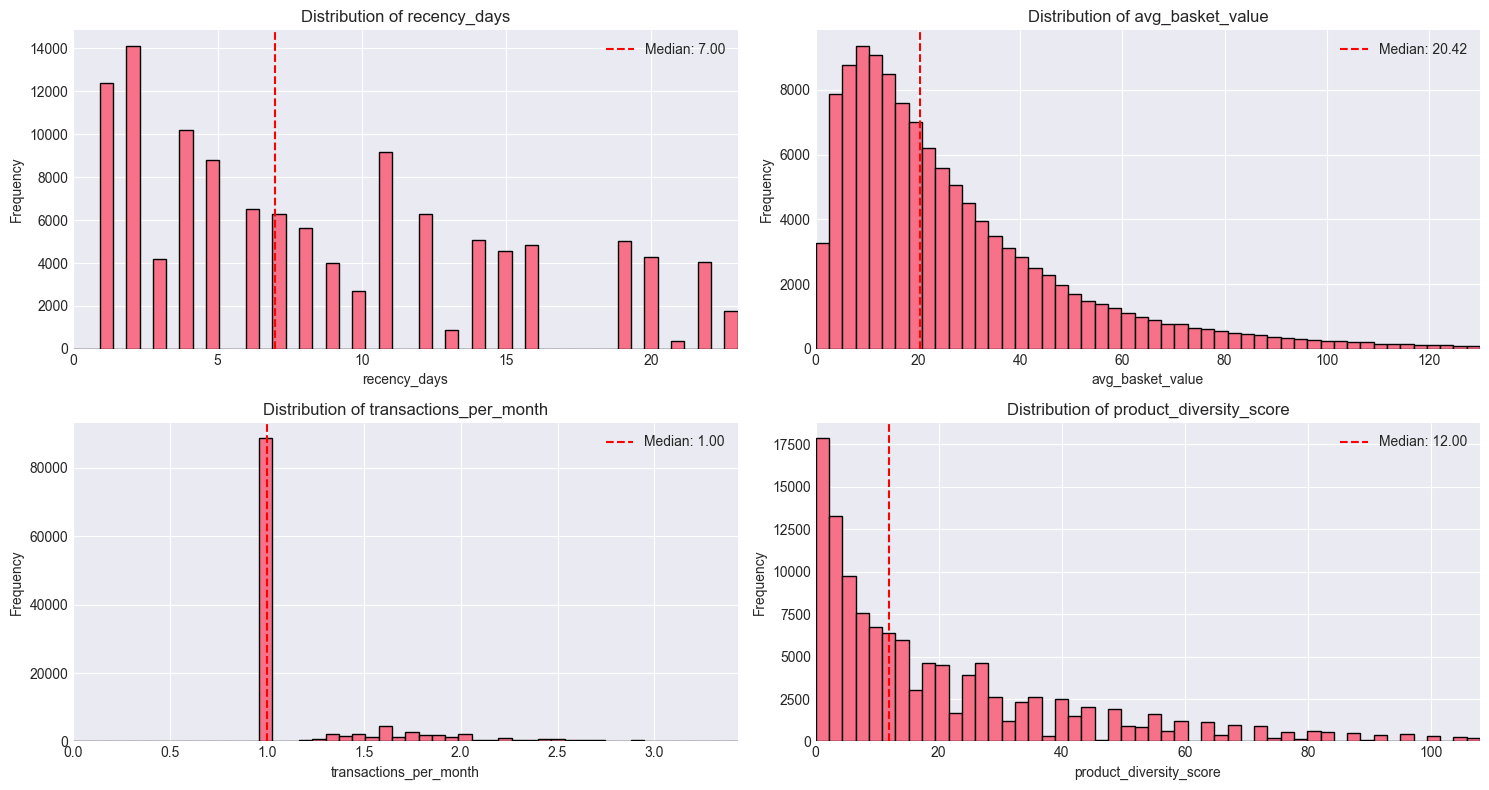

✓ Distribution plots saved as 'feature_distributions.png'


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# STEP 3.1: Distribution Analysis
# ============================================================================

print("\n[STEP 3.1] Analyzing feature distributions...")

key_features = [
    "recency_days",
    "avg_basket_value",
    "transactions_per_month",
    "product_diversity_score",
]

# --- settings
BINS = 50
CAP_AT_QUANTILE = 0.99  # set to None to disable cap (e.g. None)
USE_LOG_X = False       # set True if you prefer log scale (don't use with range cap)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    ax = axes[idx]

    if feature not in customer_features.columns:
        ax.set_title(f"{feature} (missing)")
        ax.axis("off")
        continue

    s = customer_features[feature].dropna()

    # Handle empty column
    if len(s) == 0:
        ax.set_title(f"Distribution of {feature} (no data)")
        ax.axis("off")
        continue

    # Optional cap on x-axis using quantile to avoid long-tail stretching the plot
    if CAP_AT_QUANTILE is not None and not USE_LOG_X:
        xmax = float(s.quantile(CAP_AT_QUANTILE))
        if np.isfinite(xmax) and xmax > 0:
            ax.hist(s, bins=BINS, edgecolor="black", range=(0, xmax))
            ax.set_xlim(0, xmax)
        else:
            ax.hist(s, bins=BINS, edgecolor="black")
    else:
        ax.hist(s, bins=BINS, edgecolor="black")

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

    med = float(s.median())
    ax.axvline(med, color="red", linestyle="--", label=f"Median: {med:.2f}")
    ax.legend()

    if USE_LOG_X:
        ax.set_xscale("log")

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✓ Distribution plots saved as 'feature_distributions.png'")


[STEP 3.2] Correlation analysis...


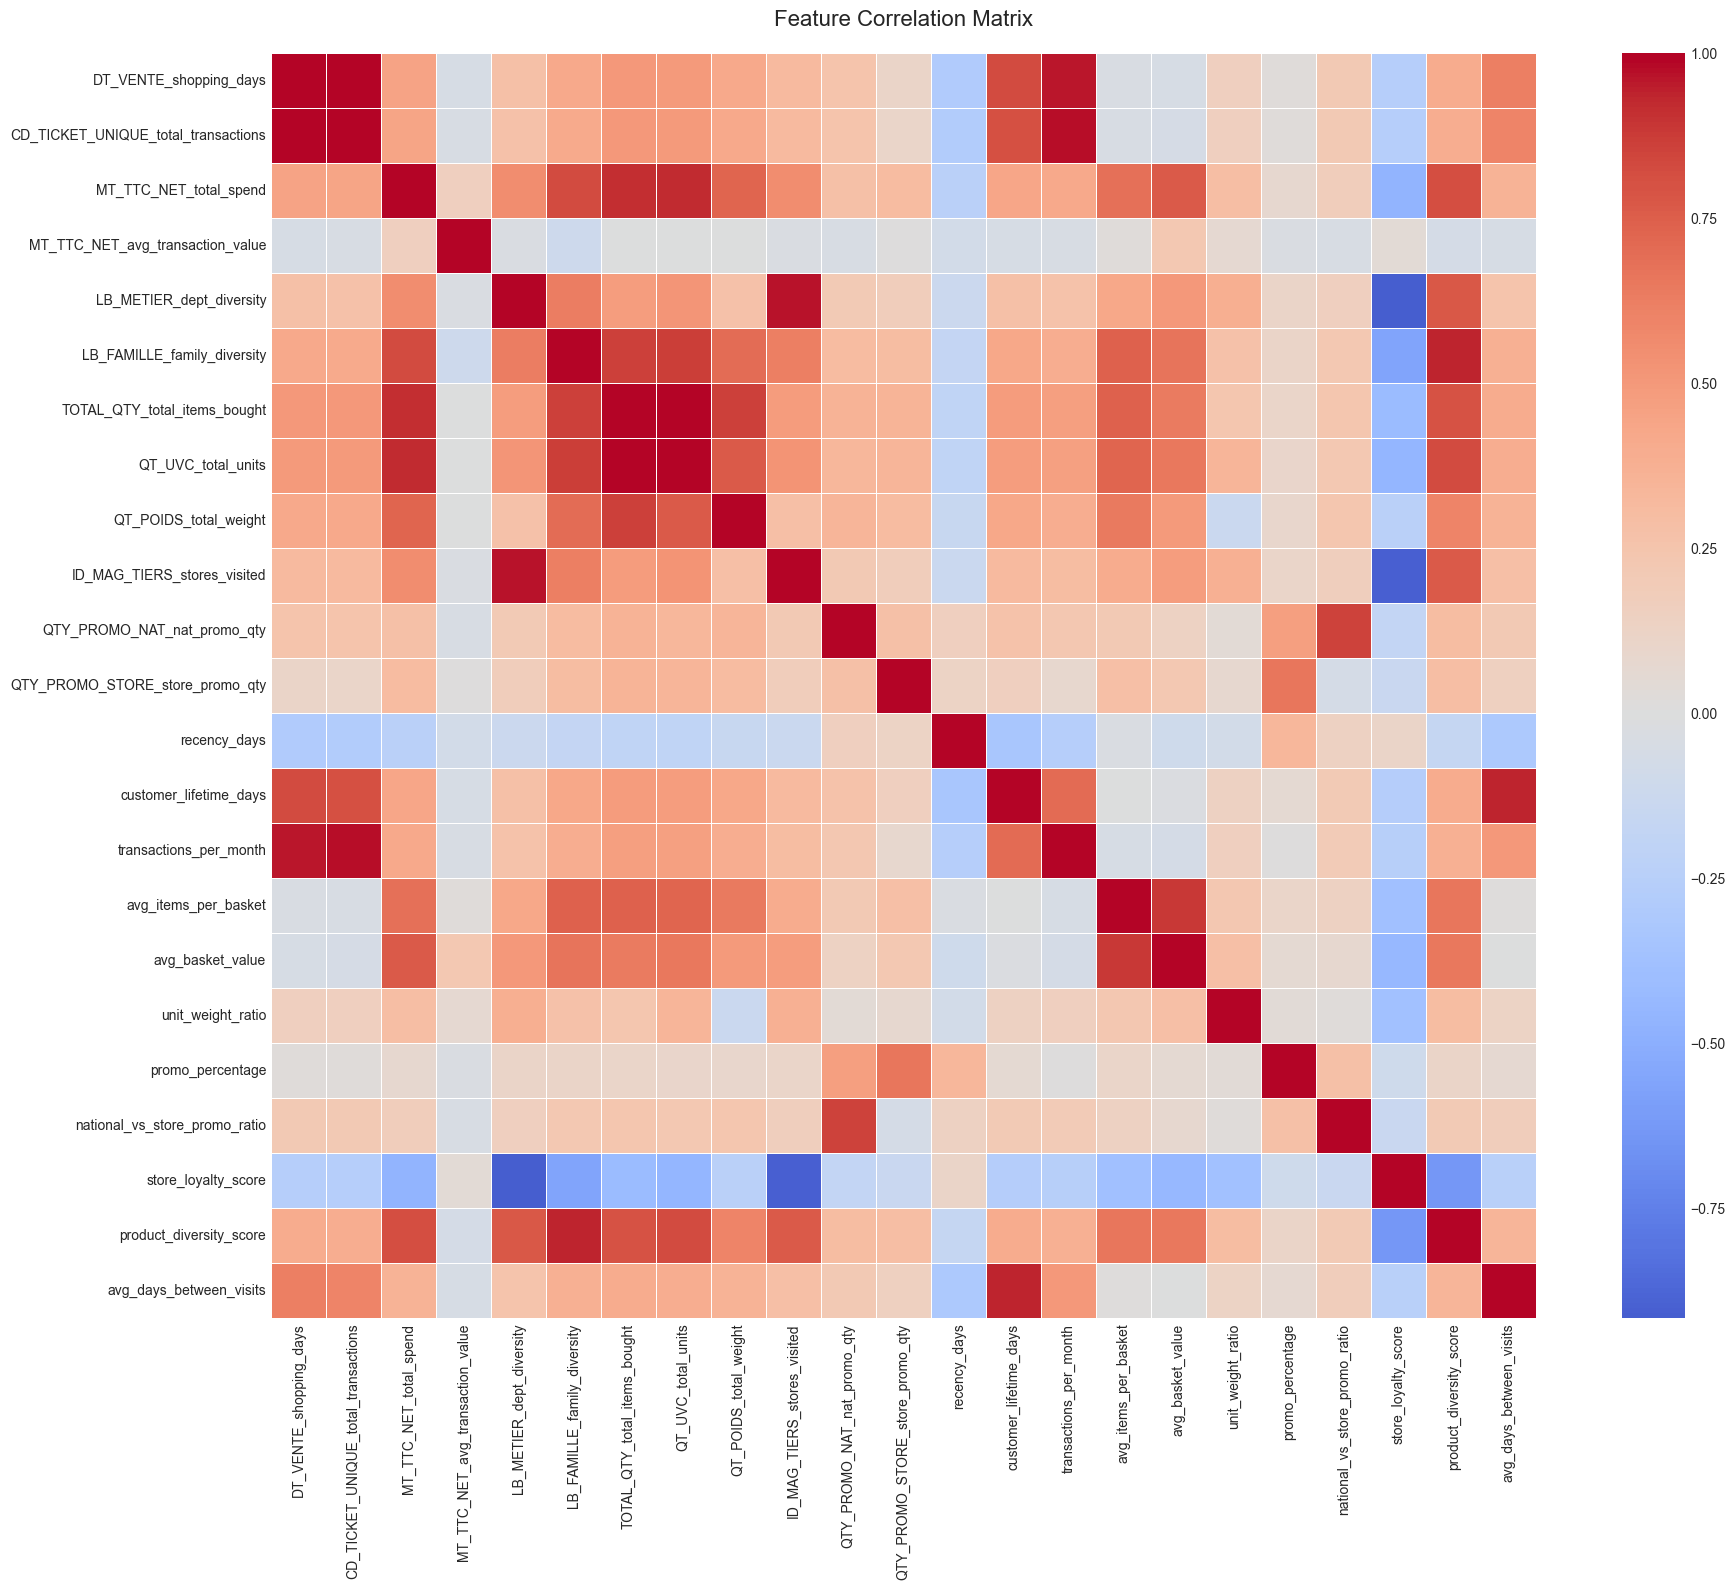

✓ Correlation matrix saved as 'correlation_matrix.png'

Highly correlated feature pairs (|r| > 0.8): 22
  DT_VENTE_shopping_days <-> CD_TICKET_UNIQUE_total_transactions: 0.988
  DT_VENTE_shopping_days <-> customer_lifetime_days: 0.824
  DT_VENTE_shopping_days <-> transactions_per_month: 0.956
  CD_TICKET_UNIQUE_total_transactions <-> customer_lifetime_days: 0.807
  CD_TICKET_UNIQUE_total_transactions <-> transactions_per_month: 0.977
  MT_TTC_NET_total_spend <-> LB_FAMILLE_family_diversity: 0.822
  MT_TTC_NET_total_spend <-> TOTAL_QTY_total_items_bought: 0.914
  MT_TTC_NET_total_spend <-> QT_UVC_total_units: 0.923
  MT_TTC_NET_total_spend <-> product_diversity_score: 0.818
  LB_METIER_dept_diversity <-> ID_MAG_TIERS_stores_visited: 0.969


In [33]:
# ============================================================================
# STEP 3.2: Correlation Analysis
# ============================================================================

print("\n[STEP 3.2] Correlation analysis...")

# Select numeric features only
numeric_features = customer_features.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns
numeric_features = [col for col in numeric_features if not col.startswith('NO_TOKEN')]

# Calculate correlation matrix
correlation_matrix = customer_features[numeric_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Correlation matrix saved as 'correlation_matrix.png'")
plt.close()

# Identify highly correlated features (|r| > 0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f"\nHighly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)}")
for feat1, feat2, corr in high_corr_pairs[:10]:
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")


[STEP 3.2] Correlation analysis...


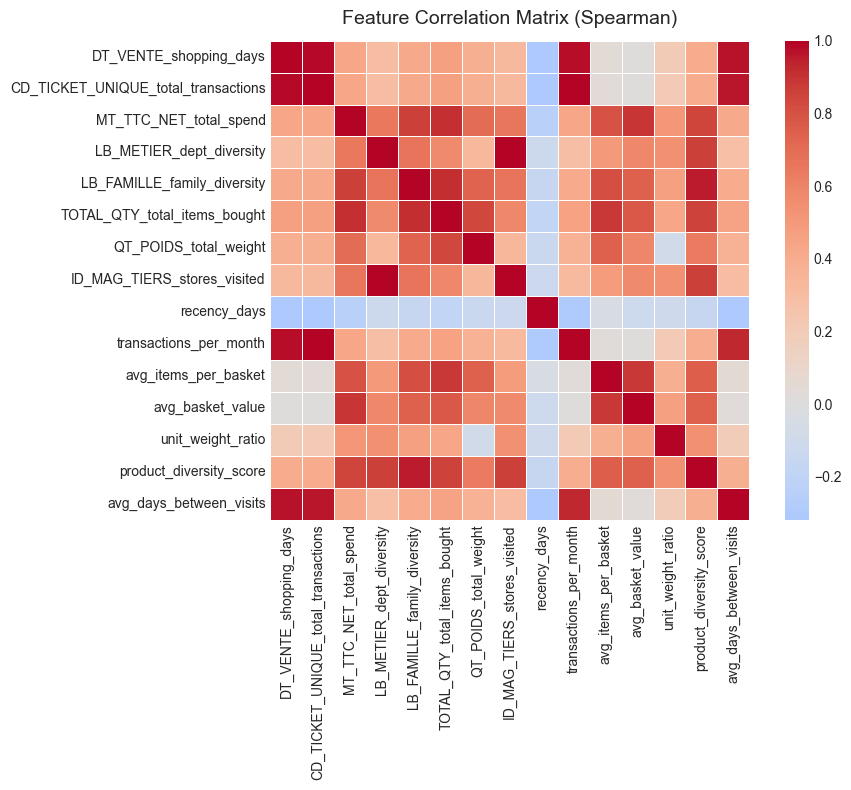

✓ Correlation matrix saved as 'correlation_matrix.png'

Highly correlated feature pairs (|r| > 0.8): 20
  DT_VENTE_shopping_days <-> CD_TICKET_UNIQUE_total_transactions: 0.986
  DT_VENTE_shopping_days <-> transactions_per_month: 0.975
  DT_VENTE_shopping_days <-> avg_days_between_visits: 0.973
  CD_TICKET_UNIQUE_total_transactions <-> transactions_per_month: 0.995
  CD_TICKET_UNIQUE_total_transactions <-> avg_days_between_visits: 0.959
  MT_TTC_NET_total_spend <-> LB_FAMILLE_family_diversity: 0.859
  MT_TTC_NET_total_spend <-> TOTAL_QTY_total_items_bought: 0.910
  MT_TTC_NET_total_spend <-> avg_basket_value: 0.889
  MT_TTC_NET_total_spend <-> product_diversity_score: 0.851
  LB_METIER_dept_diversity <-> ID_MAG_TIERS_stores_visited: 0.990


In [34]:
# ============================================================================
# STEP 3.3: Correlation Analysis simplified
# ============================================================================

print("\n[STEP 3.2] Correlation analysis...")

# Select numeric features only
numeric_features = customer_features.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns
numeric_features = [col for col in numeric_features if not col.startswith("NO_TOKEN")]

# Exclude specific variables
exclude_cols = [
    "store_loyalty_score",
    "national_vs_store_promo_ratio",
    "promo_percentage",
    "QTY_PROMO_STORE_store_promo_qty",
    "QTY_PROMO_NAT_nat_promo_qty",
    "ID_LIEU_DE_VENTE_stores_visited",
    "MT_TTC_NET_avg_transaction_value",
    "QT_UVC_total_units",
    "customer_lifetime_days",
]
numeric_features = [c for c in numeric_features if c not in exclude_cols]

# Calculate correlation matrix
correlation_matrix = customer_features[numeric_features].corr(method="spearman")

# Plot correlation heatmap (smaller)
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Matrix (Spearman)", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Correlation matrix saved as 'correlation_matrix.png'")
plt.close()

# Identify highly correlated features (|r| > 0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f"\nHighly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)}")
for feat1, feat2, corr in high_corr_pairs[:10]:
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")


[STEP 3.3] RFM Analysis visualization...


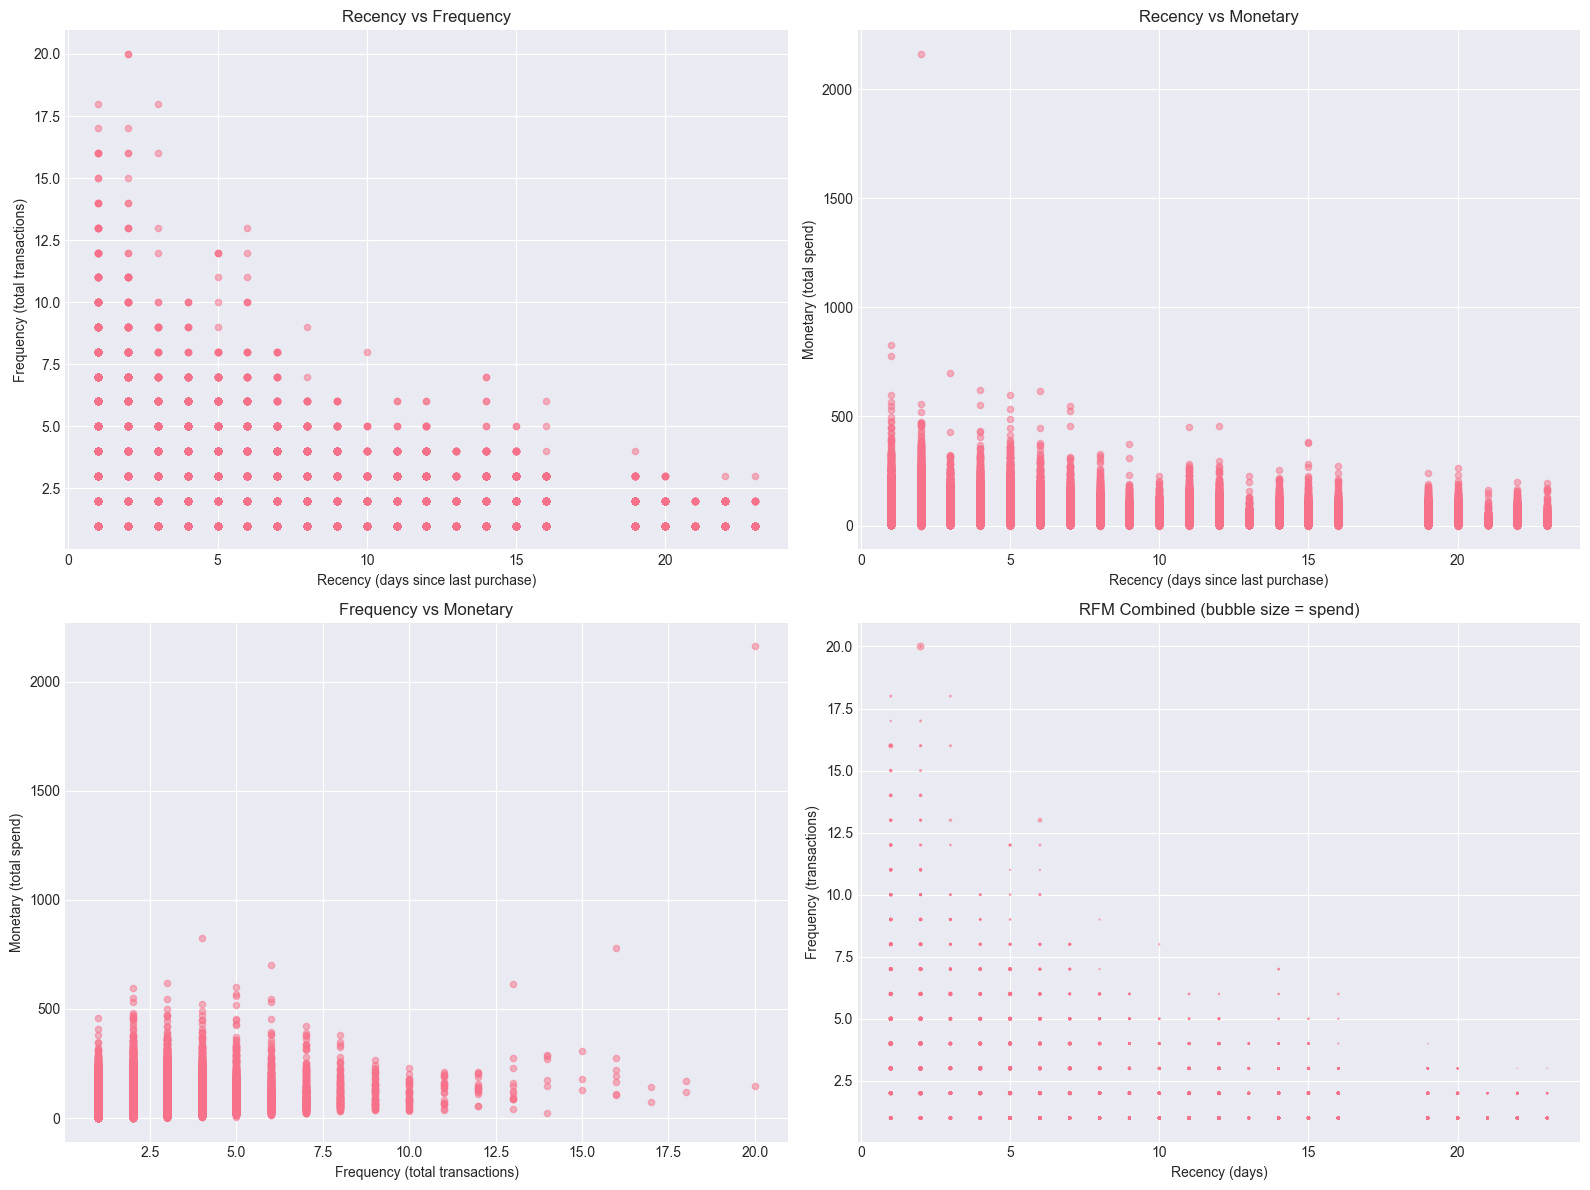

✓ RFM analysis plots saved as 'rfm_analysis.png'


In [35]:
# ============================================================================
# STEP 3.3: RFM Analysis Visualization
# ============================================================================

print("\n[STEP 3.3] RFM Analysis visualization...")

# Create RFM scatter plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Recency vs Frequency
axes[0, 0].scatter(customer_features['recency_days'],
                   customer_features['CD_TICKET_UNIQUE_total_transactions'],
                   alpha=0.5, s=20)
axes[0, 0].set_xlabel('Recency (days since last purchase)')
axes[0, 0].set_ylabel('Frequency (total transactions)')
axes[0, 0].set_title('Recency vs Frequency')

# Recency vs Monetary
axes[0, 1].scatter(customer_features['recency_days'],
                   customer_features['MT_TTC_NET_total_spend'],
                   alpha=0.5, s=20)
axes[0, 1].set_xlabel('Recency (days since last purchase)')
axes[0, 1].set_ylabel('Monetary (total spend)')
axes[0, 1].set_title('Recency vs Monetary')

# Frequency vs Monetary
axes[1, 0].scatter(customer_features['CD_TICKET_UNIQUE_total_transactions'],
                   customer_features['MT_TTC_NET_total_spend'],
                   alpha=0.5, s=20)
axes[1, 0].set_xlabel('Frequency (total transactions)')
axes[1, 0].set_ylabel('Monetary (total spend)')
axes[1, 0].set_title('Frequency vs Monetary')

# 3D-like representation using bubble size
axes[1, 1].scatter(customer_features['recency_days'],
                   customer_features['CD_TICKET_UNIQUE_total_transactions'],
                   s=customer_features['MT_TTC_NET_total_spend']/100,
                   alpha=0.5)
axes[1, 1].set_xlabel('Recency (days)')
axes[1, 1].set_ylabel('Frequency (transactions)')
axes[1, 1].set_title('RFM Combined (bubble size = spend)')

plt.tight_layout()
plt.show()
plt.savefig('rfm_analysis.png', dpi=300, bbox_inches='tight')
print("✓ RFM analysis plots saved as 'rfm_analysis.png'")
plt.close()

In [36]:
## Here the RFM analysis shows a very good information first, that there is a real relationship between recency and frequency, the less recency the more frequency
## Another good info is that the less recency the more monetary (more or less) which is good i we could identify a first segment here.
## Frequency monetary graph show that more frequency more monetary
## Bubble chart useless

In [37]:
# ============================================================================
# PART 4: CLUSTERING PREPARATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 4: CLUSTERING PREPARATION")
print("=" * 80)


PART 4: CLUSTERING PREPARATION


In [38]:
# ============================================================================
# STEP 4.1: Feature Selection for Clustering
# ============================================================================

print("\n[STEP 4.1] Selecting features for clustering...")

# Define clustering features (remove highly correlated and redundant features)
clustering_features = [
    # RFM Core
    'recency_days',
    'MT_TTC_NET_total_spend',

    # Behavioral
    'avg_basket_value',
    'transactions_per_month',

    # Product preferences
    'product_diversity_score',

    # Promotional behavior
    'promo_percentage',

    # Store behavior
    'store_loyalty_score',

]

# Filter features that exist in dataframe
clustering_features = [f for f in clustering_features if f in customer_features.columns]

print(f"Selected {len(clustering_features)} features for clustering:")
for i, feat in enumerate(clustering_features, 1):
    print(f"  {i}. {feat}")

# Create clustering dataset
df_clustering = customer_features[['NO_TOKEN'] + clustering_features].copy()

# Handle missing values
print(f"\nMissing values before imputation:\n{df_clustering[clustering_features].isnull().sum()}")
df_clustering[clustering_features] = df_clustering[clustering_features].fillna(
    df_clustering[clustering_features].median()
)

# Handle infinite values
df_clustering[clustering_features] = df_clustering[clustering_features].replace(
    [np.inf, -np.inf], np.nan
).fillna(df_clustering[clustering_features].median())

print(f"✓ Clustering dataset prepared: {df_clustering.shape}")



[STEP 4.1] Selecting features for clustering...
Selected 7 features for clustering:
  1. recency_days
  2. MT_TTC_NET_total_spend
  3. avg_basket_value
  4. transactions_per_month
  5. product_diversity_score
  6. promo_percentage
  7. store_loyalty_score

Missing values before imputation:
recency_days               0
MT_TTC_NET_total_spend     0
avg_basket_value           0
transactions_per_month     0
product_diversity_score    0
promo_percentage           0
store_loyalty_score        0
dtype: int64
✓ Clustering dataset prepared: (121112, 8)


In [39]:
# ============================================================================
# STEP 4.2: Feature Scaling
# ============================================================================

print("\n[STEP 4.2] Scaling features...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering[clustering_features])

print(f"✓ Features scaled using StandardScaler")
print(f"  Shape: {X_scaled.shape}")
print(f"  Mean: {X_scaled.mean():.6f}")
print(f"  Std: {X_scaled.std():.6f}")


[STEP 4.2] Scaling features...
✓ Features scaled using StandardScaler
  Shape: (121112, 7)
  Mean: 0.000000
  Std: 1.000000



[STEP 3.3] Correlation analysis (clustering_features)...


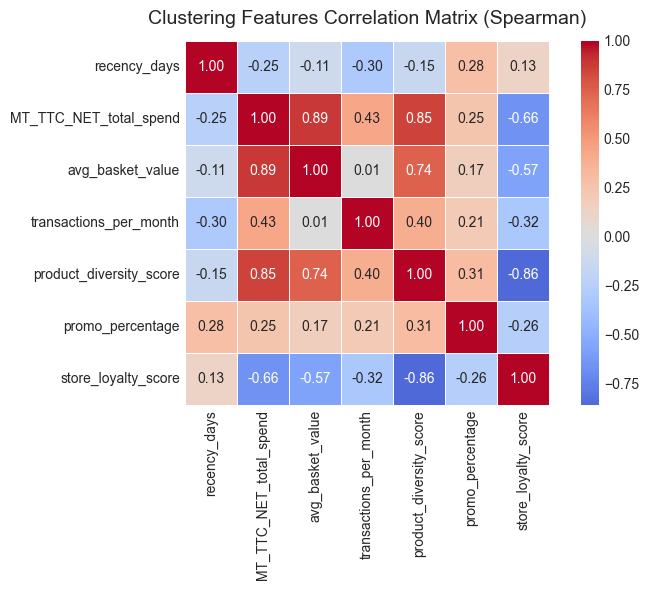

✓ Correlation matrix saved as 'correlation_matrix_clustering_features.png'

Highly correlated feature pairs (|r| > 0.8): 3
  MT_TTC_NET_total_spend <-> avg_basket_value: 0.889
  MT_TTC_NET_total_spend <-> product_diversity_score: 0.851
  product_diversity_score <-> store_loyalty_score: -0.861


In [40]:
# ============================================================================
# STEP 3.3: Correlation Analysis (clustering_features only)
# ============================================================================

print("\n[STEP 3.3] Correlation analysis (clustering_features)...")

clustering_features = [
    # RFM Core
    "recency_days",
    "MT_TTC_NET_total_spend",
    # Behavioral
    "avg_basket_value",
    "transactions_per_month",
    # Product preferences
    "product_diversity_score",
    # Promotional behavior
    "promo_percentage",
    # Store behavior
    "store_loyalty_score",
]

# Keep only columns that exist + are numeric
existing = [c for c in clustering_features if c in customer_features.columns]
missing = [c for c in clustering_features if c not in customer_features.columns]
if missing:
    print(f"⚠ Missing columns (ignored): {missing}")

numeric_existing = customer_features[existing].select_dtypes(include=[np.number]).columns.tolist()
non_numeric = [c for c in existing if c not in numeric_existing]
if non_numeric:
    print(f"⚠ Non-numeric columns (ignored): {non_numeric}")

features = numeric_existing

# Correlation matrix (Spearman)
correlation_matrix = customer_features[features].corr(method="spearman")

# Plot correlation heatmap (smaller)
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # small matrix -> readable
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Clustering Features Correlation Matrix (Spearman)", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("correlation_matrix_clustering_features.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Correlation matrix saved as 'correlation_matrix_clustering_features.png'")
plt.close()

# Identify highly correlated features (|r| > 0.8)
high_corr_pairs = []
cols = correlation_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = correlation_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append((cols[i], cols[j], r))

print(f"\nHighly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)}")
for feat1, feat2, corr in high_corr_pairs:
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")

In [41]:
# ============================================================================
# PART 5: ACP
# ============================================================================

print("\n" + "=" * 80)
print("PART 5: K-MEANS CLUSTERING")
print("=" * 80)


PART 5: K-MEANS CLUSTERING


In [42]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA


def create_combinaison(customer_features, X_cols, method="mean"):
    print("\n[STEP 0] Creating 'combinaison' feature...")

    X_df = customer_features[X_cols].copy()
    X_df = X_df.select_dtypes(include=[np.number]).dropna()

    print(f"Using {len(X_df):,} rows to build 'combinaison'")
    print(f"X_cols = {X_cols}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)

    if method == "mean":
        combinaison = X_scaled.mean(axis=1)
    elif method == "sum":
        combinaison = X_scaled.sum(axis=1)
    else:
        raise ValueError("method must be either 'mean' or 'sum'")

    customer_features.loc[X_df.index, "combinaison"] = combinaison

    print("✓ 'combinaison' created")

    return customer_features, scaler


def determine_optimal_clusters(customer_features, profile_metrics, combinaison="combinaison"):
    print("\n[STEP 1] Determining optimal number of clusters...")

    features_to_use = profile_metrics.copy()
    if combinaison not in features_to_use:
        features_to_use.append(combinaison)

    existing = [c for c in features_to_use if c in customer_features.columns]
    missing = [c for c in features_to_use if c not in customer_features.columns]
    if missing:
        print(f"⚠ Missing columns (ignored): {missing}")

    X_df = customer_features[existing].select_dtypes(include=[np.number]).copy()
    X_df = X_df.dropna()

    used_features = X_df.columns.tolist()
    print(f"Using {len(used_features)} features: {used_features}")
    print(f"Rows used for clustering: {len(X_df):,}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)

    k_range = range(2, 11)
    inertias, silhouette_scores, davies_bouldin_scores = [], [], []

    for k in k_range:
        print(f"  Testing k={k}...", end=" ")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        labels = kmeans.fit_predict(X_scaled)

        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
        print("Done")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(list(k_range), inertias, "bo-")
    axes[0].set_xlabel("Number of Clusters (k)")
    axes[0].set_ylabel("Inertia")
    axes[0].set_title("Elbow Method")
    axes[0].grid(True)

    axes[1].plot(list(k_range), silhouette_scores, "go-")
    axes[1].set_xlabel("Number of Clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].set_title("Silhouette Score")
    axes[1].grid(True)

    axes[2].plot(list(k_range), davies_bouldin_scores, "ro-")
    axes[2].set_xlabel("Number of Clusters (k)")
    axes[2].set_ylabel("Davies-Bouldin Score")
    axes[2].set_title("Davies-Bouldin Score")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

    optimal_k_silhouette = list(k_range)[int(np.argmax(silhouette_scores))]
    optimal_k_db = list(k_range)[int(np.argmin(davies_bouldin_scores))]

    print("\nRecommended number of clusters:")
    print(f"  Based on Silhouette Score: k={optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
    print(f"  Based on Davies-Bouldin Score: k={optimal_k_db} (score: {min(davies_bouldin_scores):.3f})")

    return {
        "X_df": X_df,
        "used_features": used_features,
        "scaler": scaler,
        "X_scaled": X_scaled,
        "k_range": list(k_range),
        "inertias": inertias,
        "silhouette_scores": silhouette_scores,
        "davies_bouldin_scores": davies_bouldin_scores,
        "optimal_k_silhouette": optimal_k_silhouette,
        "optimal_k_db": optimal_k_db,
    }


def final_clustering(customer_features, profile_metrics, combinaison, optimal_k):
    print(f"\n[STEP 2] Performing final clustering with k={optimal_k}...")

    features_to_use = profile_metrics.copy()
    if combinaison not in features_to_use:
        features_to_use.append(combinaison)

    existing = [c for c in features_to_use if c in customer_features.columns]
    missing = [c for c in features_to_use if c not in customer_features.columns]
    if missing:
        print(f"⚠ Missing columns (ignored): {missing}")

    df_clustering = customer_features[existing].select_dtypes(include=[np.number]).copy()
    df_clustering = df_clustering.dropna()

    used_features = df_clustering.columns.tolist()

    print(f"Using {len(used_features)} features: {used_features}")
    print(f"Rows used for clustering: {len(df_clustering):,}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clustering)

    kmeans_final = KMeans(
        n_clusters=optimal_k,
        random_state=42,
        n_init=20,
        max_iter=500
    )

    df_clustering["Cluster"] = kmeans_final.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, df_clustering["Cluster"])
    db_score = davies_bouldin_score(X_scaled, df_clustering["Cluster"])

    print("✓ Clustering complete")
    print(f"  Silhouette Score: {sil_score:.3f}")
    print(f"  Davies-Bouldin Score: {db_score:.3f}")

    cluster_counts = df_clustering["Cluster"].value_counts().sort_index()
    cluster_percentages = (
        df_clustering["Cluster"].value_counts(normalize=True).sort_index() * 100
    ).round(2)

    print("\nCluster distribution:")
    print(cluster_counts)

    print("\nCluster percentages:")
    print(cluster_percentages)

    return {
        "df_clustering": df_clustering,
        "used_features": used_features,
        "scaler": scaler,
        "X_scaled": X_scaled,
        "kmeans_final": kmeans_final,
        "silhouette_score": sil_score,
        "davies_bouldin_score": db_score,
        "cluster_counts": cluster_counts,
        "cluster_percentages": cluster_percentages,
    }


def plot_pca_clusters(X_scaled, df_clustering, optimal_k, cluster_col="Cluster"):
    print("\n[STEP 3] Creating PCA visualization...")

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=df_clustering[cluster_col],
        cmap="viridis",
        alpha=0.6,
        s=50
    )

    plt.xlabel(f"First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)")
    plt.ylabel(f"Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)")
    plt.title(f"Customer Segments Visualization (k={optimal_k})")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

    explained_variance = pca.explained_variance_ratio_[:2].sum()
    print(f"PCA explained variance (2 components): {explained_variance:.1%}")

    return {
        "pca": pca,
        "X_pca": X_pca,
        "explained_variance_2d": explained_variance
    }


def clustering_pipeline(customer_features, X_cols, all_metrics, combinaison_method="mean"):
    print("\n========== CLUSTERING PIPELINE ==========")

    profile_metrics = [col for col in all_metrics if col not in X_cols]

    print("X_cols =", X_cols)
    print("profile_metrics =", profile_metrics)

    customer_features, scaler_comb = create_combinaison(
        customer_features=customer_features,
        X_cols=X_cols,
        method=combinaison_method
    )

    k_results = determine_optimal_clusters(
        customer_features=customer_features,
        profile_metrics=profile_metrics,
        combinaison="combinaison"
    )

    print("\nTu peux maintenant choisir k.")
    print(f"Suggestion silhouette: {k_results['optimal_k_silhouette']}")
    print(f"Suggestion Davies-Bouldin: {k_results['optimal_k_db']}")

    optimal_k = int(input("Entre la valeur de k que tu veux utiliser : "))

    clustering_results = final_clustering(
        customer_features=customer_features,
        profile_metrics=profile_metrics,
        combinaison="combinaison",
        optimal_k=optimal_k
    )

    pca_results = plot_pca_clusters(
        X_scaled=clustering_results["X_scaled"],
        df_clustering=clustering_results["df_clustering"],
        optimal_k=optimal_k,
        cluster_col="Cluster"
    )

    return {
        "customer_features": customer_features,
        "profile_metrics": profile_metrics,
        "scaler_comb": scaler_comb,
        "k_results": k_results,
        "optimal_k": optimal_k,
        "clustering_results": clustering_results,
        "pca_results": pca_results
    }

X_cols = ['transactions_per_month', 'avg_basket_value', 'recency_days']
profile_metrics = ['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score']

[STEP 0] Creating 'combinaison' feature...
Using 121,112 rows to build 'combinaison'
X_cols = ['transactions_per_month', 'avg_basket_value', 'recency_days']
✓ 'combinaison' created

[STEP 1] Determining optimal number of clusters...
Using 6 features: ['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score', 'combinaison']
Rows used for clustering: 121,112
  Testing k=2... Done
  Testing k=3... Done
  Testing k=4... Done
  Testing k=5... Done
  Testing k=6... Done
  Testing k=7... Done
  Testing k=8... Done
  Testing k=9... Done
  Testing k=10... Done


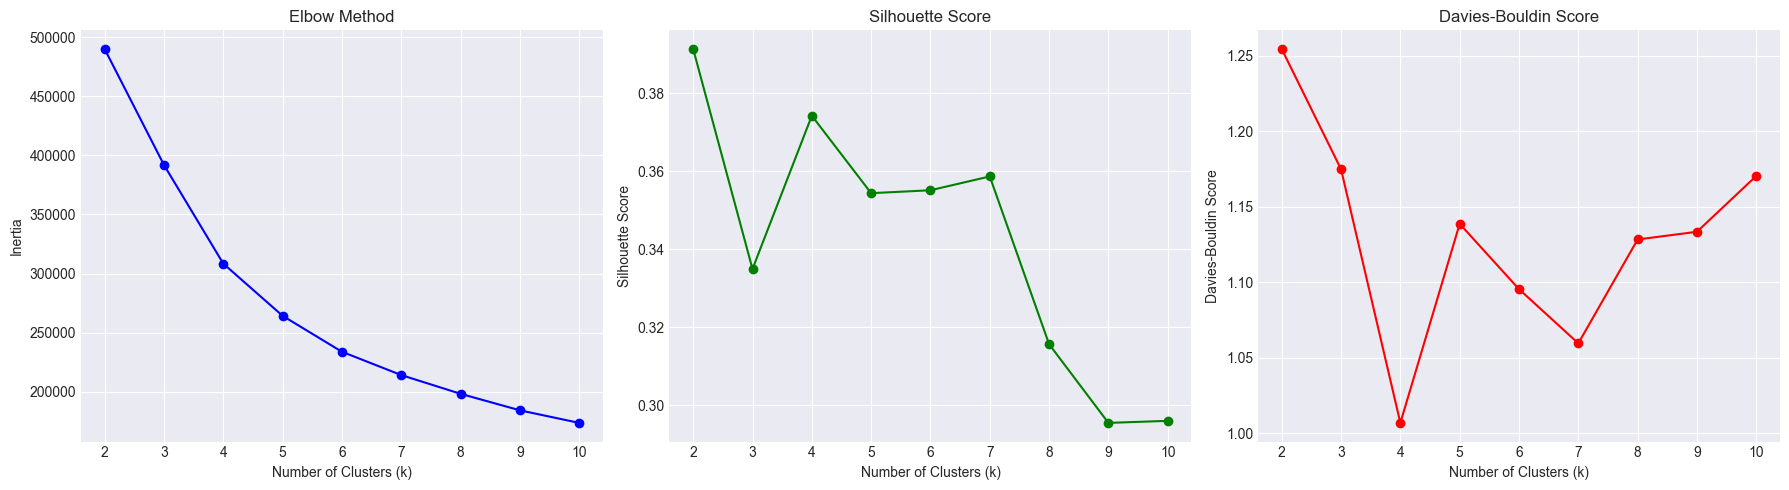


Recommended number of clusters:
  Based on Silhouette Score: k=2 (score: 0.391)
  Based on Davies-Bouldin Score: k=4 (score: 1.007)


In [43]:
# ============================================================================
# STEP 1 : définir X_cols, créer combinaison, afficher les métriques de choix de k
# ============================================================================

all_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
]

X_cols = ["transactions_per_month", "avg_basket_value", "recency_days"]

profile_metrics = [col for col in all_metrics if col not in X_cols]

print("X_cols =", X_cols)
print("profile_metrics =", profile_metrics)

# 1) créer combinaison
customer_features, scaler_comb = create_combinaison(
    customer_features=customer_features,
    X_cols=X_cols,
    method="mean"
)

# 2) afficher les métriques pour choisir k
k_results = determine_optimal_clusters(
    customer_features=customer_features,
    profile_metrics=profile_metrics,
    combinaison="combinaison"
)


[STEP 2] Performing final clustering with k=4...
Using 6 features: ['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score', 'combinaison']
Rows used for clustering: 121,112
✓ Clustering complete
  Silhouette Score: 0.374
  Davies-Bouldin Score: 1.006

Cluster distribution:
Cluster
0    62627
1     6925
2    17509
3    34051
Name: count, dtype: int64

Cluster percentages:
Cluster
0   51.710
1    5.720
2   14.460
3   28.120
Name: proportion, dtype: float64

[STEP 3] Creating PCA visualization...


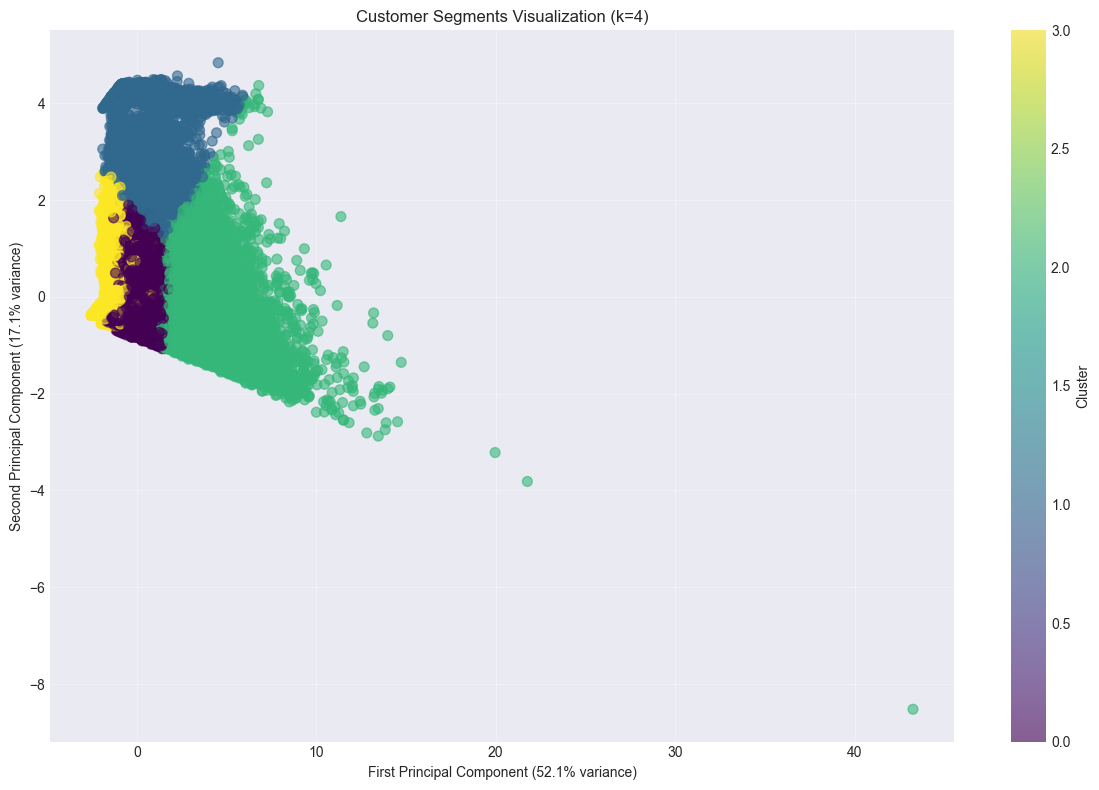

PCA explained variance (2 components): 69.2%
        CD_TICKET_UNIQUE_total_transactions  MT_TTC_NET_total_spend  \
0                                         2                  26.590   
1                                         4                  71.550   
2                                         1                  37.040   
3                                         2                  49.390   
4                                         1                  21.980   
...                                     ...                     ...   
121107                                    1                   2.470   
121108                                    1                   1.190   
121109                                    2                  18.810   
121110                                    1                  12.460   
121111                                    2                  28.310   

        promo_percentage  product_diversity_score  store_loyalty_score  \
0                 18.129    

In [44]:
# ============================================================================
# STEP 2 : choisir k manuellement, puis clustering final + PCA
# ============================================================================

chosen_k = 4

clustering_results = final_clustering(
    customer_features=customer_features,
    profile_metrics=profile_metrics,
    combinaison="combinaison",
    optimal_k=chosen_k
)

df_clustering = clustering_results["df_clustering"]

pca_results = plot_pca_clusters(
    X_scaled=clustering_results["X_scaled"],
    df_clustering=df_clustering,
    optimal_k=chosen_k,
    cluster_col="Cluster"
)

print(df_clustering)

In [45]:
df_clustering.columns

Index(['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend',
       'promo_percentage', 'product_diversity_score', 'store_loyalty_score',
       'combinaison', 'Cluster'],
      dtype='str')

In [46]:
# ============================================================================
# PART 6: SEGMENT CHARACTERIZATION (merge clusters back)
# ============================================================================

print("\n" + "=" * 80)
print("PART 6: SEGMENT CHARACTERIZATION")
print("=" * 80)

id_col = "NO_TOKEN"

if id_col not in customer_features.columns:
    raise KeyError(f"'{id_col}' not found in customer_features")

# df_clustering est souvent construit sans l'ID (car non numérique)
if id_col not in df_clustering.columns:
    cluster_map = customer_features.loc[df_clustering.index, [id_col]].copy()
    cluster_map["Cluster"] = df_clustering["Cluster"].values
else:
    cluster_map = df_clustering[[id_col, "Cluster"]].copy()

customer_segments = customer_features.merge(
    cluster_map,
    on=id_col,
    how="left"
)

print("✓ Merge done")
print("  Rows:", len(customer_segments))
print("  Unassigned clusters:", int(customer_segments["Cluster"].isna().sum()))


PART 6: SEGMENT CHARACTERIZATION
✓ Merge done
  Rows: 121112
  Unassigned clusters: 0


In [47]:
# ============================================================================
# STEP 6.1: Statistical Segment Profiles (mean + count + %)
# ============================================================================

print("\n[STEP 6.1] Creating segment profiles...")

profile_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
    "combinaison",  # inclure la variable créée
]

# Garder uniquement les métriques présentes
profile_metrics = [m for m in profile_metrics if m in customer_segments.columns]

# Assurer que Cluster existe
if "Cluster" not in customer_segments.columns:
    raise KeyError("'Cluster' not found in customer_segments")

# Segment profiles (mean)
segment_profiles = customer_segments.groupby("Cluster")[profile_metrics].mean()

# Ajouter volume et pourcentage
cluster_counts = customer_segments["Cluster"].value_counts().sort_index()
cluster_pct = (customer_segments["Cluster"].value_counts(normalize=True).sort_index() * 100).round(2)

segment_profiles = segment_profiles.join(cluster_counts.rename("n")).join(cluster_pct.rename("pct"))

print("\nSegment Profiles (Mean values):")
print("=" * 100)
print(segment_profiles.round(2))

# Save to CSV



[STEP 6.1] Creating segment profiles...

Segment Profiles (Mean values):
         recency_days  CD_TICKET_UNIQUE_total_transactions  \
Cluster                                                      
0               8.340                                1.280   
1              16.060                                1.240   
2               5.800                                2.660   
3               9.300                                1.130   

         MT_TTC_NET_total_spend  avg_basket_value  transactions_per_month  \
Cluster                                                                     
0                        32.150            27.380                   1.170   
1                        38.650            32.460                   1.130   
2                       111.290            58.880                   1.950   
3                        14.880            13.300                   1.080   

         promo_percentage  product_diversity_score  store_loyalty_score  \
Cluster        


[STEP 6.2] Characterizing segments...


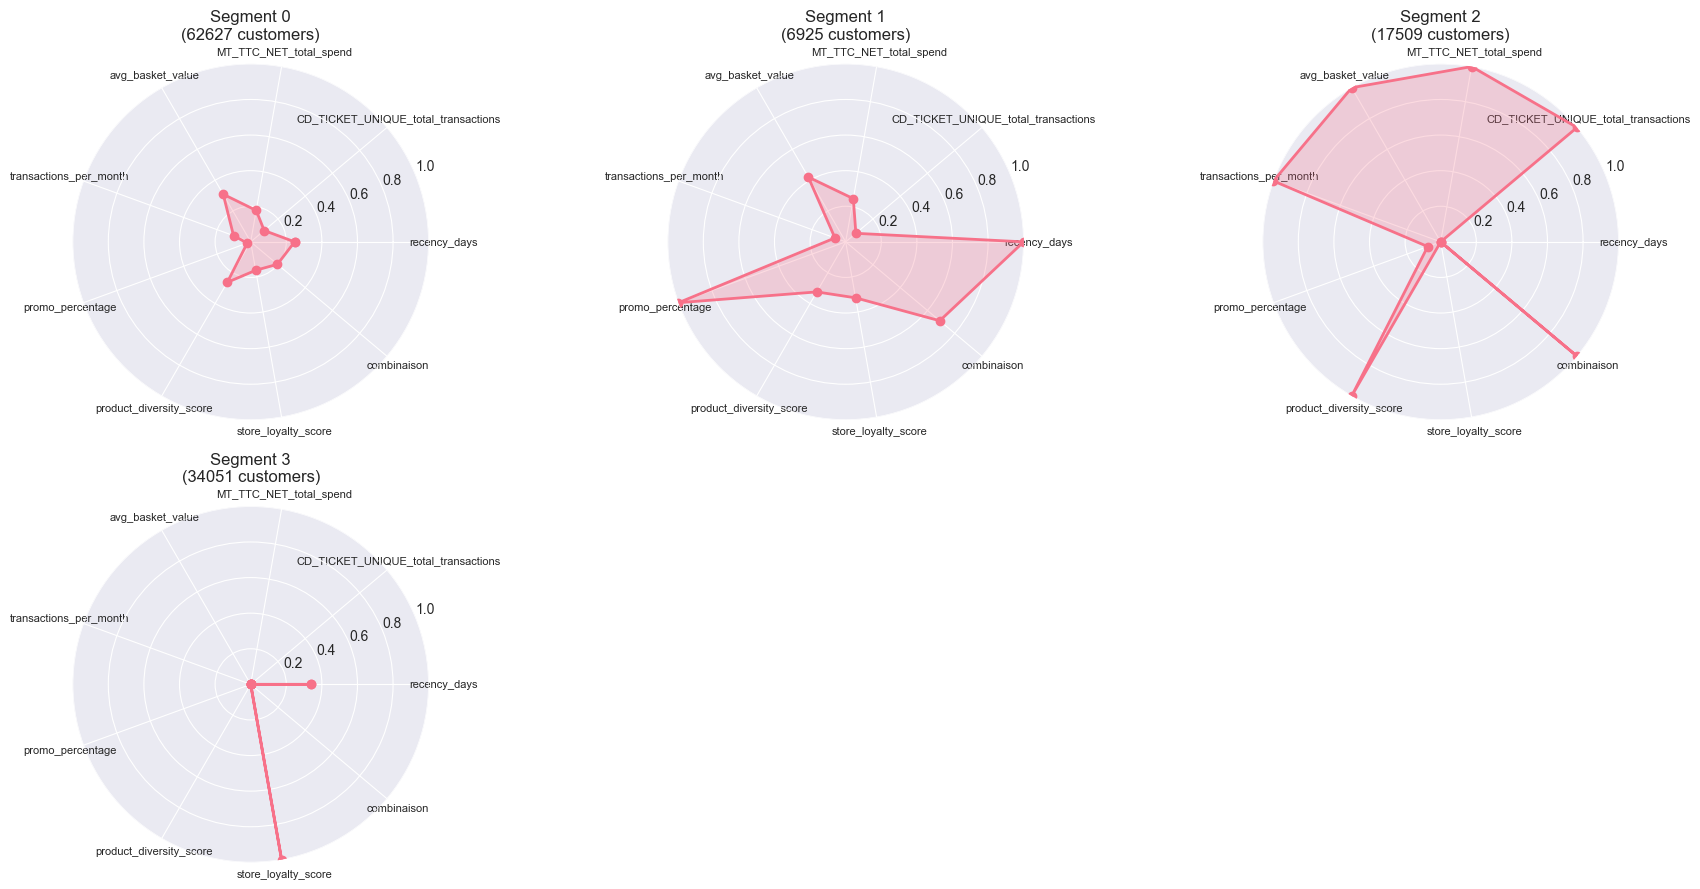

✓ Segment radar charts saved as 'segment_radar_charts.png'


In [48]:
# ============================================================================
# STEP 6.2: Segment Naming and Characterization (Radar charts)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("\n[STEP 6.2] Characterizing segments...")

# Metrics à afficher (recalcul proprement depuis segment_profiles)
# -> on exclut n/pct si tu les as ajoutés dans step 6.1
plot_metrics = [c for c in segment_profiles.columns if c not in ["n", "pct"]]

# Angles radar
angles = np.linspace(0, 2 * np.pi, len(plot_metrics), endpoint=False).tolist()
angles += angles[:1]

# Grille de subplots adaptée à optimal_k
optimal_k = 4
n_clusters = int(optimal_k)
n_cols = 3
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows),
    subplot_kw=dict(projection="polar")
)

# axes peut être 2D si n_rows>1, sinon 1D
axes = np.array(axes).reshape(-1)

# Normalisation min-max par métrique (sur tous les clusters)
mins = segment_profiles[plot_metrics].min(axis=0)
maxs = segment_profiles[plot_metrics].max(axis=0)
den = (maxs - mins).replace(0, np.nan)  # éviter division par 0

for idx, cluster_id in enumerate(sorted(segment_profiles.index.tolist())):
    if idx >= len(axes):
        break
    ax = axes[idx]

    # Valeurs du cluster (seulement les métriques)
    values = segment_profiles.loc[cluster_id, plot_metrics]
    values_norm = ((values - mins) / den).fillna(0.0).values.tolist()
    values_norm += values_norm[:1]

    ax.plot(angles, values_norm, "o-", linewidth=2)
    ax.fill(angles, values_norm, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(plot_metrics, size=8)
    ax.set_ylim(0, 1)

    n_customers = int(customer_segments["Cluster"].eq(cluster_id).sum())
    ax.set_title(f"Segment {cluster_id}\n({n_customers} customers)", size=12, pad=18)
    ax.grid(True)

# Supprimer les axes inutilisés
for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("segment_radar_charts.png", dpi=300, bbox_inches="tight")  # save BEFORE show
plt.show()
print("✓ Segment radar charts saved as 'segment_radar_charts.png'")
plt.close()

In [49]:
# ============================================================================
# STEP 6.3: Business Insights Summary (adapted)
# ============================================================================

print("\n[STEP 6.3] Generating business insights...")

# Colonnes à agréger (on garde uniquement celles qui existent)
id_col = "NO_TOKEN_CB"
agg_spec = {}

if id_col in customer_segments.columns:
    agg_spec[id_col] = "count"

if "MT_TTC_NET_total_spend" in customer_segments.columns:
    agg_spec["MT_TTC_NET_total_spend"] = ["sum", "mean"]

if "CD_TICKET_UNIQUE_total_transactions" in customer_segments.columns:
    agg_spec["CD_TICKET_UNIQUE_total_transactions"] = "mean"

if "recency_days" in customer_segments.columns:
    agg_spec["recency_days"] = "mean"

if "promo_percentage" in customer_segments.columns:
    agg_spec["promo_percentage"] = "mean"

if "store_loyalty_score" in customer_segments.columns:
    agg_spec["store_loyalty_score"] = "mean"

if "combinaison" in customer_segments.columns:
    agg_spec["combinaison"] = "mean"

if "Cluster" not in customer_segments.columns:
    raise KeyError("'Cluster' not found in customer_segments")

segment_summary = customer_segments.groupby("Cluster").agg(agg_spec).round(2)

# Aplatir les colonnes multi-index (sum/mean)
segment_summary.columns = [
    "_".join([str(x) for x in col if x]).strip("_") if isinstance(col, tuple) else col
    for col in segment_summary.columns
]

# Renommer proprement si présent
rename_map = {
    id_col: "Customer_Count",
    "MT_TTC_NET_total_spend_sum": "Total_Revenue",
    "MT_TTC_NET_total_spend_mean": "Avg_Revenue_Per_Customer",
    "CD_TICKET_UNIQUE_total_transactions": "Avg_Transactions",
    "recency_days": "Avg_Recency",
    "promo_percentage": "Avg_Promo_%",
    "store_loyalty_score": "Avg_Store_Loyalty",
    "combinaison": "Avg_Combinaison",
}
segment_summary = segment_summary.rename(columns={k: v for k, v in rename_map.items() if k in segment_summary.columns})

# Revenue contribution (%)
if "Total_Revenue" in segment_summary.columns:
    segment_summary["Revenue_%"] = (
        segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum() * 100
    ).round(2)

print("\nSegment Business Summary:")
print("=" * 120)
print(segment_summary)

# Save results



[STEP 6.3] Generating business insights...

Segment Business Summary:
         Total_Revenue  Avg_Revenue_Per_Customer  \
Cluster                                            
0          2013686.830                    32.150   
1           267636.180                    38.650   
2          1948643.840                   111.290   
3           506645.800                    14.880   

         CD_TICKET_UNIQUE_total_transactions_mean  recency_days_mean  \
Cluster                                                                
0                                           1.280              8.340   
1                                           1.240             16.060   
2                                           2.660              5.800   
3                                           1.130              9.300   

         promo_percentage_mean  store_loyalty_score_mean  combinaison_mean  \
Cluster                                                                      
0                        4.

In [50]:
print("\n" + "=" * 80)
print("CLUSTERING ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nSegments created: {optimal_k}")
print(f"Total customers segmented: {len(customer_segments)}")
print("\nKey outputs generated:")
print("  1. feature_distributions.png")
print("  2. correlation_matrix.png")
print("  3. rfm_analysis.png")
print("  4. clustering_metrics.png")
print("  5. cluster_visualization_pca.png")
print("  6. segment_radar_charts.png")
print("  7. segment_profiles.csv")
print("  8. segment_business_summary.csv")
print("  9. customers_with_segments.csv")
print("\nProceeding to association rules and recommendations!")



CLUSTERING ANALYSIS COMPLETE!

Segments created: 4
Total customers segmented: 121112

Key outputs generated:
  1. feature_distributions.png
  2. correlation_matrix.png
  3. rfm_analysis.png
  4. clustering_metrics.png
  5. cluster_visualization_pca.png
  6. segment_radar_charts.png
  7. segment_profiles.csv
  8. segment_business_summary.csv
  9. customers_with_segments.csv

Proceeding to association rules and recommendations!


In [51]:
# ============================================================================
# PART X: ALTERNATIVE CLUSTERING METHODS
# DBSCAN  ·  Agglomerative Hierarchical  ·  Gaussian Mixture Model (GMM)
# + Full comparison with K-Means (k=4)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster        import DBSCAN, AgglomerativeClustering
from sklearn.mixture        import GaussianMixture
from sklearn.decomposition  import PCA
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (silhouette_score, davies_bouldin_score,
                                    calinski_harabasz_score, adjusted_rand_score,
                                    normalized_mutual_info_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance  import cdist

print("✓ All imports loaded.")


✓ All imports loaded.


In [52]:
# ============================================================================
# SHARED SETUP — feature matrix used by all methods
# ============================================================================
# Mirrors the original K-Means exactly:
#   X_cols      = [transactions_per_month, avg_basket_value, recency_days]
#   combinaison = mean of scaled X_cols  (already on customer_features)
#   Clustering input = profile_metrics + combinaison
#     where profile_metrics = all_metrics - X_cols
# ============================================================================

all_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
]

X_cols = ["transactions_per_month", "avg_basket_value", "recency_days"]

# Rebuild combinaison (mean of scaled X_cols) in case this cell runs standalone
_x_df = customer_features[X_cols].select_dtypes(include=[np.number]).copy()
_x_df.fillna(_x_df.median(), inplace=True)
_scaler_comb = StandardScaler()
_x_scaled = _scaler_comb.fit_transform(_x_df)
customer_features["combinaison"] = np.nan
customer_features.loc[_x_df.index, "combinaison"] = _x_scaled.mean(axis=1)
print("✓ combinaison rebuilt")

# Clustering features = profile_metrics + combinaison  (same as original K-Means)
profile_metrics = [col for col in all_metrics if col not in X_cols]
CLUSTERING_FEATURES = profile_metrics + ["combinaison"]
CLUSTERING_FEATURES = [f for f in CLUSTERING_FEATURES if f in customer_features.columns]

print(f"Clustering features ({len(CLUSTERING_FEATURES)}): {CLUSTERING_FEATURES}")

df_clust = customer_features[CLUSTERING_FEATURES].copy()
df_clust.fillna(df_clust.median(), inplace=True)
for col in df_clust.columns:
    median_val = df_clust[col].median()
    df_clust[col] = df_clust[col].replace([np.inf, -np.inf], median_val)

scaler_shared = StandardScaler()
X = scaler_shared.fit_transform(df_clust)

# PCA for 2-D visualisation (computed once, reused by all methods)
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X)
var_explained = pca2.explained_variance_ratio_.sum()

print(f"Feature matrix : {X.shape}")
print(f"PCA 2-D variance explained : {var_explained:.1%}")

# K-Means labels (k=4) — reference baseline
from sklearn.cluster import KMeans
km_ref = KMeans(n_clusters=4, random_state=42, n_init=20, max_iter=500)
labels_kmeans = km_ref.fit_predict(X)
print(f"K-Means (k=4) — Silhouette: {silhouette_score(X, labels_kmeans):.3f}")


✓ combinaison rebuilt
Clustering features (6): ['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score', 'combinaison']
Feature matrix : (121112, 6)
PCA 2-D variance explained : 69.2%
K-Means (k=4) — Silhouette: 0.374


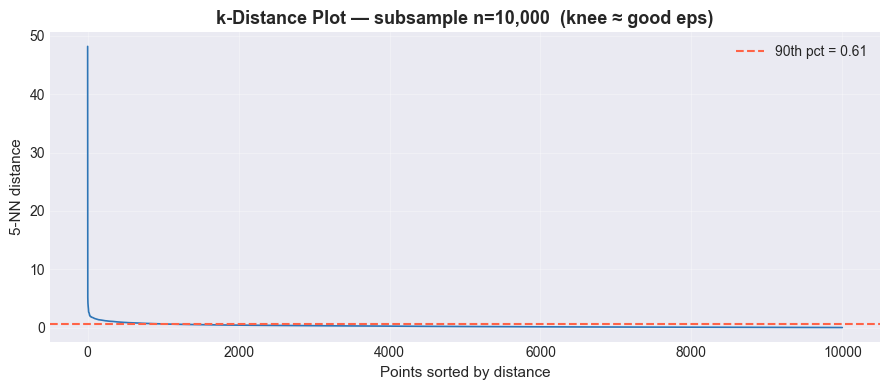

Top-10 DBSCAN configurations:
  eps  min_samples  n_clusters  noise_pct  silhouette  davies_bouldin
1.200           10           2      0.300       0.292           1.161
1.200           20           2      0.500       0.289           1.156
1.200            5           4      0.200       0.283           0.732
1.200           30           2      0.600       0.282           1.153
0.300           20          17     16.500       0.208           1.173
0.300           30          16     19.500       0.175           1.210
0.800           30          10      2.200       0.173           2.071
1.000           30          11      1.200       0.170           2.211
0.700            5          37      1.000       0.169           1.224
0.800            5          27      0.700       0.168           1.451
Best DBSCAN: eps=1.2, min_samples=10
  Clusters found : 2
  Noise points   : 360 (0.3%)
  Silhouette     : 0.292
  Davies-Bouldin : 1.161


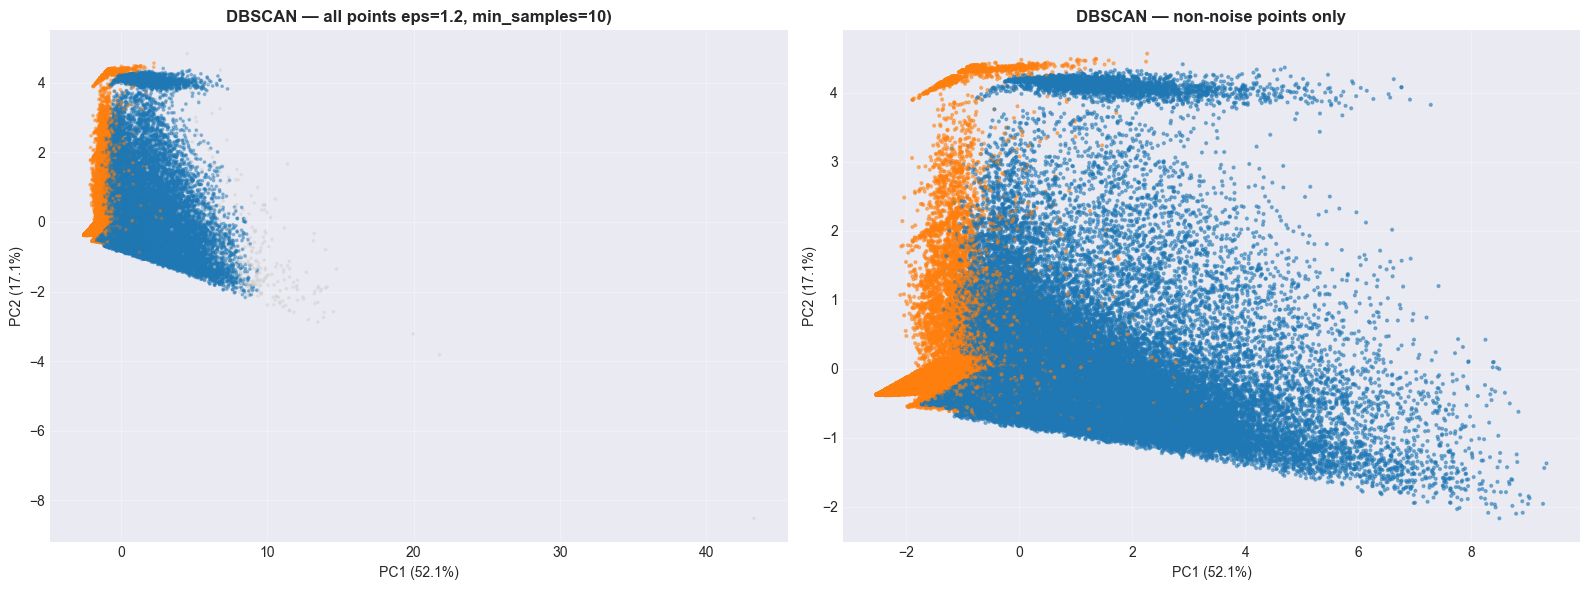

✓ DBSCAN complete.


In [55]:
# ============================================================================
# DBSCAN  — Density-Based Spatial Clustering
# ============================================================================
# Optimised for 121k rows:
#   • k-distance plot on a 10k subsample (representative, ~12x faster)
#   • Grid search uses sample_size in silhouette_score
#   • n_jobs=-1 throughout
# ============================================================================

from sklearn.neighbors import NearestNeighbors

# --- 1) k-distance plot on subsample ----------------------------------------
K_NN        = 5
KDIST_N     = 10_000   # subsample for k-distance plot

np.random.seed(42)
_idx_kd  = np.random.choice(len(X), size=KDIST_N, replace=False)
X_kd     = X[_idx_kd]

nbrs     = NearestNeighbors(n_neighbors=K_NN, n_jobs=-1).fit(X_kd)
dists, _ = nbrs.kneighbors(X_kd)
k_dist   = np.sort(dists[:, K_NN - 1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_dist, linewidth=1.2, color="#2E75B6")
ax.set_xlabel("Points sorted by distance", fontsize=11)
ax.set_ylabel(f"{K_NN}-NN distance", fontsize=11)
ax.set_title(f"k-Distance Plot — subsample n={KDIST_N:,}  (knee ≈ good eps)",
             fontsize=13, fontweight="bold")
_pct90 = np.percentile(k_dist, 90)
ax.axhline(y=_pct90, color="tomato", linestyle="--",
           label=f"90th pct = {_pct90:.2f}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_kdist.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 2) Grid search with fast silhouette ------------------------------------
# silhouette_score uses sample_size=5k to avoid O(n²) computation
EPS_GRID      = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]
MINSAMP_GRID  = [5, 10, 20, 30]
SIL_SAMPLE    = 5_000

results_db = []
for eps in EPS_GRID:
    for ms in MINSAMP_GRID:
        lbl        = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct  = (lbl == -1).mean() * 100
        if n_clusters >= 2 and noise_pct < 30:
            mask = lbl != -1
            sil  = silhouette_score(X[mask], lbl[mask],
                                    sample_size=min(SIL_SAMPLE, mask.sum()),
                                    random_state=42)
            dbs  = davies_bouldin_score(X[mask], lbl[mask])
            results_db.append(dict(eps=eps, min_samples=ms,
                                   n_clusters=n_clusters, noise_pct=round(noise_pct,1),
                                   silhouette=sil, davies_bouldin=dbs))

df_db_grid = pd.DataFrame(results_db).sort_values("silhouette", ascending=False)
print("Top-10 DBSCAN configurations:")
print(df_db_grid.head(10).to_string(index=False))

# --- 3) Best configuration --------------------------------------------------
best_db      = df_db_grid.iloc[0]
best_eps     = best_db["eps"]
best_ms      = int(best_db["min_samples"])
labels_dbscan = DBSCAN(eps=best_eps, min_samples=best_ms, n_jobs=-1).fit_predict(X)

print(f"Best DBSCAN: eps={best_eps}, min_samples={best_ms}")
print(f"  Clusters found : {int(best_db['n_clusters'])}")
print(f"  Noise points   : {(labels_dbscan==-1).sum():,} ({(labels_dbscan==-1).mean()*100:.1f}%)")
print(f"  Silhouette     : {best_db['silhouette']:.3f}")
print(f"  Davies-Bouldin : {best_db['davies_bouldin']:.3f}")

# --- 4) PCA plots -----------------------------------------------------------
cmap_db       = plt.get_cmap("tab10")
color_list_db = ["lightgrey" if l == -1 else cmap_db(l % 10) for l in labels_dbscan]
mask_nn       = labels_dbscan != -1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=color_list_db, s=3, alpha=0.4, rasterized=True)
axes[0].set_title(f"DBSCAN — all points eps={best_eps}, min_samples={best_ms})",fontsize=12, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")

axes[1].scatter(X_pca[mask_nn, 0], X_pca[mask_nn, 1],
                c=[cmap_db(l % 10) for l in labels_dbscan[mask_nn]],
                s=4, alpha=0.5, rasterized=True)
axes[1].set_title("DBSCAN — non-noise points only", fontsize=12, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_pca.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✓ DBSCAN complete.")


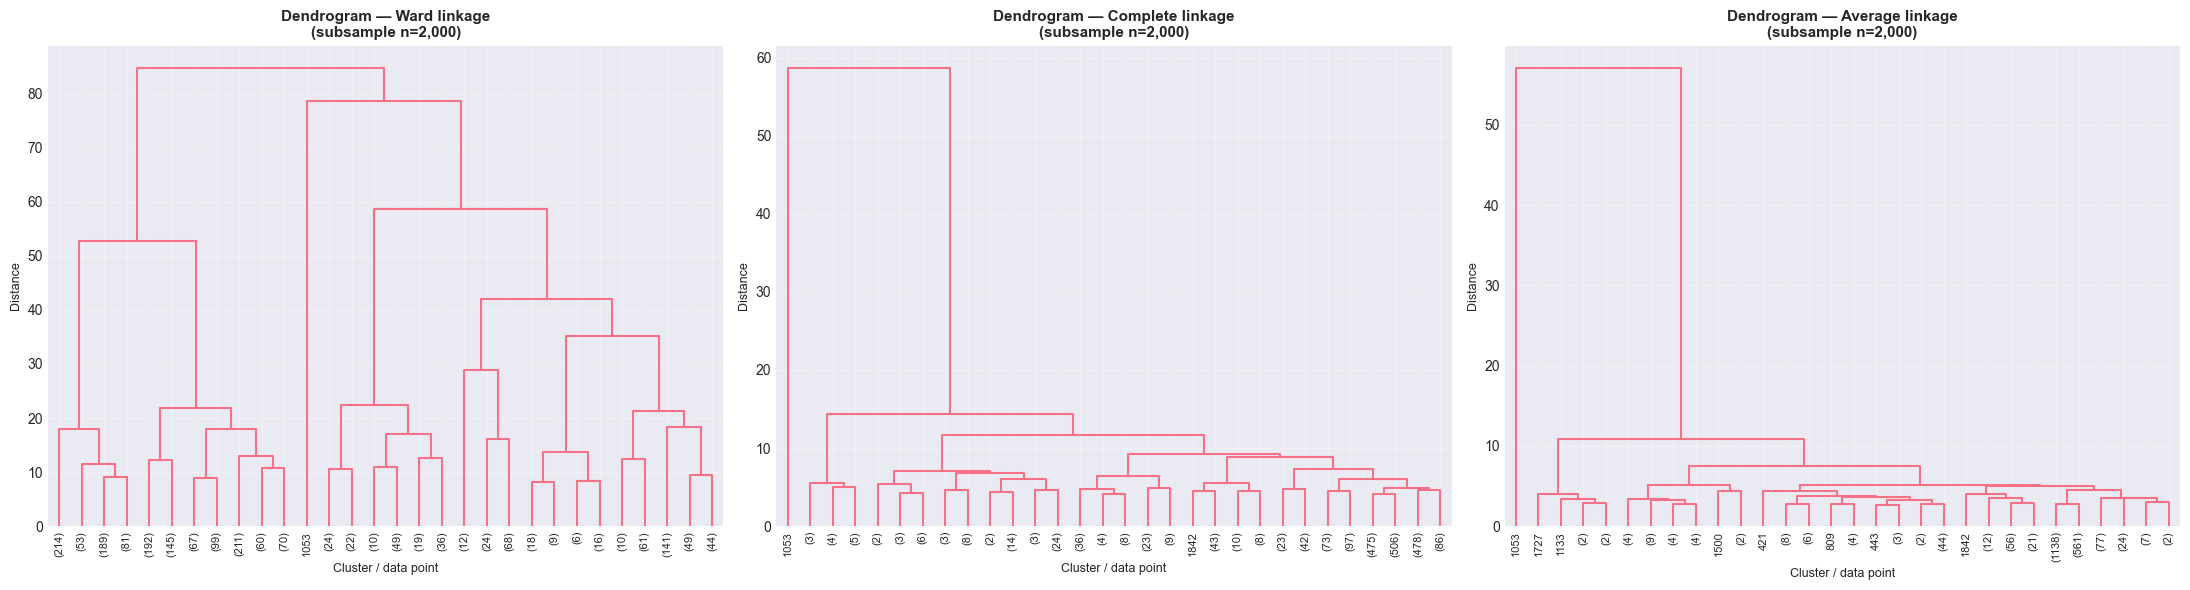

AHC fit sample : (20000, 6)  |  full dataset : (121112, 6)

Silhouette scores — linkage comparison (k=4, sample n=20k):
  ward      : Silhouette=0.345  Davies-Bouldin=1.056
  complete  : Silhouette=0.678  Davies-Bouldin=0.301
  average   : Silhouette=0.722  Davies-Bouldin=0.429

Best linkage: average

Propagating cluster labels to 121,112 customers via 5-NN...
✓ Labels propagated to full dataset

k-sweep (ward linkage, sample n=20k):
  k=2: Silhouette=0.455
  k=3: Silhouette=0.298
  k=4: Silhouette=0.345
  k=5: Silhouette=0.259
  k=6: Silhouette=0.265
  k=7: Silhouette=0.270
  k=8: Silhouette=0.271


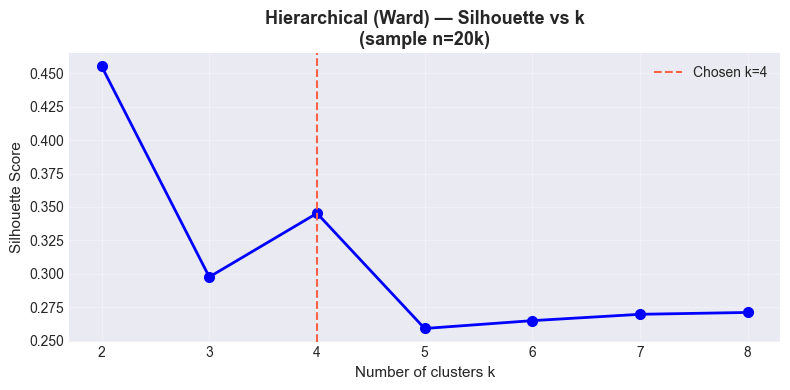

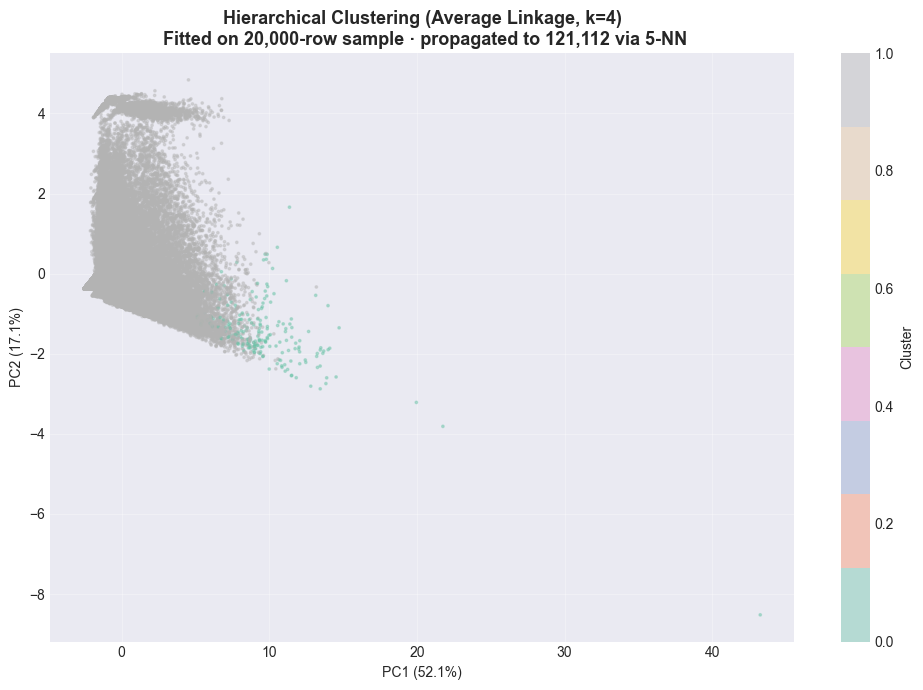


Cluster distribution (hierarchical, average, full 121,112 customers):
  Cluster 0: 210  (0.2%)
  Cluster 1: 120,902  (99.8%)
✓ Hierarchical clustering complete.


In [56]:
# ============================================================================
# AGGLOMERATIVE HIERARCHICAL CLUSTERING
# ============================================================================
# AHC memory crash at 121k rows:
#   sklearn AgglomerativeClustering builds a full merge tree — O(n^2) RAM.
#   Fix: fit on a 20k stratified sample, propagate labels to all 121k via KNN.
#   Dendrogram uses 2k subsample (linkage matrix itself is O(n^2) — keep tiny).
#   k-sweep and linkage comparison run on the 20k sample for consistency.
# ============================================================================

from sklearn.neighbors import KNeighborsClassifier

HIER_K     = 4
HIER_N     = 20_000   # sample size for AHC fit  (safe RAM budget)
DENDRO_N   = 2_000    # sample size for dendrogram only
SIL_SAMPLE = 5_000

# --- 1) Dendrogram on 2k subsample ------------------------------------------
np.random.seed(42)
_idx_d = np.random.choice(len(X), size=DENDRO_N, replace=False)
X_sub  = X[_idx_d]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, method in zip(axes, ["ward", "complete", "average"]):
    Z = linkage(X_sub, method=method)
    dendrogram(Z, ax=ax, truncate_mode="lastp", p=30,
               leaf_rotation=90, leaf_font_size=8, color_threshold=0)
    ax.set_title(f"Dendrogram — {method.capitalize()} linkage\n(subsample n={DENDRO_N:,})",fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster / data point", fontsize=9)
    ax.set_ylabel("Distance", fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hierarchical_dendrograms.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 2) Draw 20k sample for AHC fit ----------------------------------------
np.random.seed(42)
idx_sample = np.random.choice(len(X), size=HIER_N, replace=False)
X_sample   = X[idx_sample]
print(f"AHC fit sample : {X_sample.shape}  |  full dataset : {X.shape}")

# --- 3) Compare linkage methods on the 20k sample ---------------------------
print("\nSilhouette scores — linkage comparison (k=4, sample n=20k):")
linkage_scores = {}
for method in ["ward", "complete", "average"]:
    lbl_s = AgglomerativeClustering(n_clusters=HIER_K, linkage=method).fit_predict(X_sample)
    sil   = silhouette_score(X_sample, lbl_s,
                             sample_size=min(SIL_SAMPLE, HIER_N), random_state=42)
    dbs   = davies_bouldin_score(X_sample, lbl_s)
    linkage_scores[method] = dict(silhouette=sil, davies_bouldin=dbs, labels_sample=lbl_s)
    print(f"  {method:10s}: Silhouette={sil:.3f}  Davies-Bouldin={dbs:.3f}")

best_linkage  = max(linkage_scores, key=lambda m: linkage_scores[m]["silhouette"])
labels_sample = linkage_scores[best_linkage]["labels_sample"]
print(f"\nBest linkage: {best_linkage}")

# --- 4) Propagate labels to full 121k via KNN -------------------------------
print(f"\nPropagating cluster labels to {len(X):,} customers via 5-NN...")
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_sample, labels_sample)
labels_hier = knn.predict(X)
print("✓ Labels propagated to full dataset")

# --- 5) k-sweep (ward on 20k sample) ----------------------------------------
print("\nk-sweep (ward linkage, sample n=20k):")
ward_sil = []
k_range  = range(2, 9)
for k in k_range:
    lbl_s = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_sample)
    sil   = silhouette_score(X_sample, lbl_s,
                             sample_size=min(SIL_SAMPLE, HIER_N), random_state=42)
    ward_sil.append(sil)
    print(f"  k={k}: Silhouette={sil:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), ward_sil, "bo-", linewidth=2, markersize=7)
ax.axvline(x=HIER_K, color="tomato", linestyle="--", label=f"Chosen k={HIER_K}")
ax.set_xlabel("Number of clusters k", fontsize=11)
ax.set_ylabel("Silhouette Score", fontsize=11)
ax.set_title("Hierarchical (Ward) — Silhouette vs k\n(sample n=20k)",fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hierarchical_silhouette_k.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 6) PCA plot — full 121k with propagated labels -------------------------
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=labels_hier, cmap="Set2", s=3, alpha=0.4, rasterized=True)
ax.set_title(
    f"Hierarchical Clustering ({best_linkage.capitalize()} Linkage, k={HIER_K})\n Fitted on {HIER_N:,}-row sample · propagated to {len(X):,} via 5-NN",fontsize=13, fontweight="bold"
)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, label="Cluster"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hierarchical_pca.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

vals, cnts = np.unique(labels_hier, return_counts=True)
print(f"\nCluster distribution (hierarchical, {best_linkage}, full {len(X):,} customers):")
for v, c in zip(vals, cnts):
    print(f"  Cluster {v}: {c:,}  ({c/len(labels_hier)*100:.1f}%)")
print("✓ Hierarchical clustering complete.")


  tied         — BIC min at k=4
  diag         — BIC min at k=8
  spherical    — BIC min at k=8
  full         — BIC at k=4: 196,009  (sweep skipped for speed)


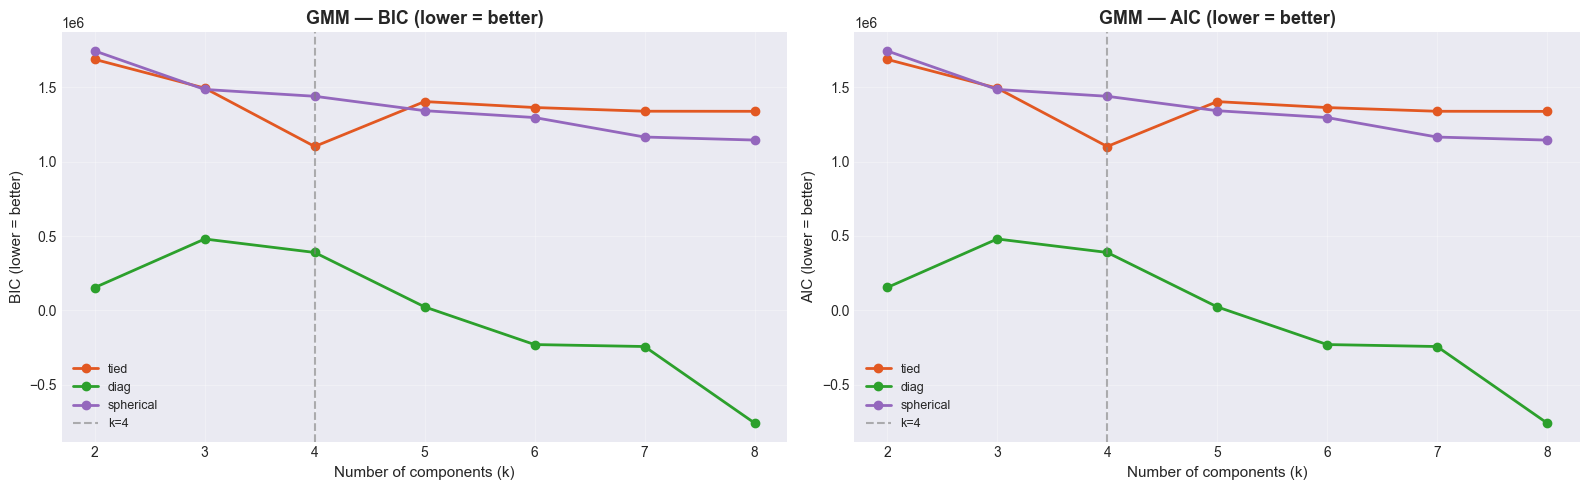

BIC at k=4 per covariance type:
  full        : 196,009  ← best
  diag        : 389,426  
  tied        : 1,101,939  
  spherical   : 1,439,522  
GMM (k=4, cov=full):
  Silhouette         : 0.254
  Davies-Bouldin     : 1.479
  Avg max P(cluster) : 0.978  (1.0 = perfectly certain)


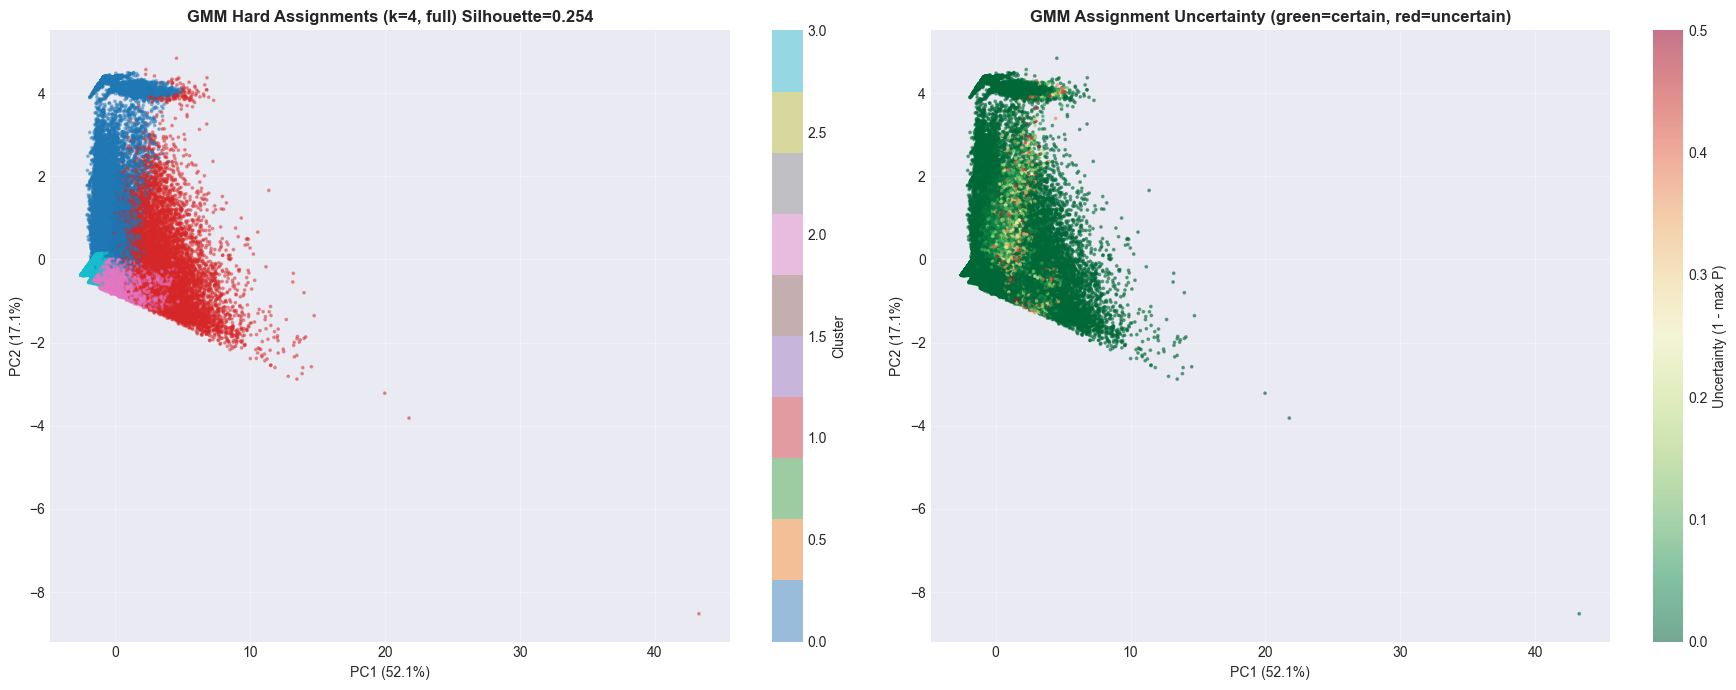

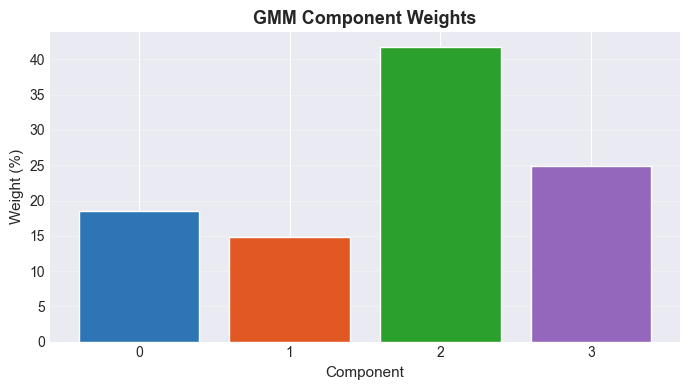

Cluster distribution (GMM):
  Cluster 0: 23,226 (19.2%)
  Cluster 1: 17,172 (14.2%)
  Cluster 2: 50,599 (41.8%)
  Cluster 3: 30,115 (24.9%)
✓ GMM complete.


In [59]:
# ============================================================================
# GAUSSIAN MIXTURE MODEL (GMM)
# ============================================================================
# Optimised for 121k rows:
#   • BIC/AIC sweep uses n_init=1 (sufficient for selection; full fit uses n_init=5)
#   • Covariance types: full dropped from sweep (very slow at 121k×6 features)
#     → included in final fit comparison only
#   • silhouette uses sample_size=5k
# ============================================================================

GMM_K      = 4
SIL_SAMPLE = 5_000

# --- 1) BIC / AIC sweep (diag, tied, spherical — skip full for speed) --------
cov_types_sweep = ["tied", "diag", "spherical"]
cov_types_all   = ["full", "tied", "diag", "spherical"]
k_range_gmm     = range(2, 9)

bic_results = {ct: [] for ct in cov_types_sweep}
aic_results = {ct: [] for ct in cov_types_sweep}

for ct in cov_types_sweep:
    for k in k_range_gmm:
        gm = GaussianMixture(n_components=k, covariance_type=ct,
                             random_state=42, max_iter=200, n_init=1)
        gm.fit(X)
        bic_results[ct].append(gm.bic(X))
        aic_results[ct].append(gm.aic(X))
    best_k_bic = k_range_gmm[np.argmin(bic_results[ct])]
    print(f"  {ct:12s} — BIC min at k={best_k_bic}")

# Add full covariance at GMM_K only (expensive to sweep)
_gm_full = GaussianMixture(n_components=GMM_K, covariance_type="full",
                           random_state=42, max_iter=200, n_init=1)
_gm_full.fit(X)
bic_full_at_k = _gm_full.bic(X)
print(f"  {'full':12s} — BIC at k={GMM_K}: {bic_full_at_k:,.0f}  (sweep skipped for speed)")

# --- 2) BIC / AIC plots -----------------------------------------------------
colors_gmm = ["#E25822", "#2CA02C", "#9467BD"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, ct in enumerate(cov_types_sweep):
    axes[0].plot(list(k_range_gmm), bic_results[ct], "o-",
                 color=colors_gmm[i], label=ct, linewidth=2)
    axes[1].plot(list(k_range_gmm), aic_results[ct], "o-",
                 color=colors_gmm[i], label=ct, linewidth=2)
for ax, title in zip(axes, ["BIC (lower = better)", "AIC (lower = better)"]):
    ax.axvline(x=GMM_K, color="grey", linestyle="--", alpha=0.6, label=f"k={GMM_K}")
    ax.set_xlabel("Number of components (k)", fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f"GMM — {title}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gmm_bic_aic.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 3) Select best covariance type at GMM_K --------------------------------
bic_at_k = {ct: bic_results[ct][GMM_K - 2] for ct in cov_types_sweep}
bic_at_k["full"] = bic_full_at_k
best_cov = min(bic_at_k, key=bic_at_k.get)
print(f"BIC at k={GMM_K} per covariance type:")
for ct, v in sorted(bic_at_k.items(), key=lambda x: x[1]):
    print(f"  {ct:12s}: {v:,.0f}  {'← best' if ct==best_cov else ''}")

# --- 4) Final GMM fit --------------------------------------------------------
gmm_best   = GaussianMixture(n_components=GMM_K, covariance_type=best_cov,
                             random_state=42, max_iter=500, n_init=5)
gmm_best.fit(X)
labels_gmm = gmm_best.predict(X)
proba_gmm  = gmm_best.predict_proba(X)
max_proba  = proba_gmm.max(axis=1)

sil_gmm = silhouette_score(X, labels_gmm, sample_size=SIL_SAMPLE, random_state=42)
db_gmm  = davies_bouldin_score(X, labels_gmm)
print(f"GMM (k={GMM_K}, cov={best_cov}):")
print(f"  Silhouette         : {sil_gmm:.3f}")
print(f"  Davies-Bouldin     : {db_gmm:.3f}")
print(f"  Avg max P(cluster) : {max_proba.mean():.3f}  (1.0 = perfectly certain)")

# --- 5) PCA scatter + uncertainty -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=labels_gmm, cmap="tab10", s=3, alpha=0.4, rasterized=True)
axes[0].set_title(f"GMM Hard Assignments (k={GMM_K}, {best_cov}) Silhouette={sil_gmm:.3f}", fontsize=12, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, ax=axes[0], label="Cluster")

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=1 - max_proba, cmap="RdYlGn_r", s=3, alpha=0.5,
                      vmin=0, vmax=0.5, rasterized=True)
axes[1].set_title("GMM Assignment Uncertainty (green=certain, red=uncertain)", fontsize=12, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc2, ax=axes[1], label="Uncertainty (1 - max P)")

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gmm_pca.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 6) Component weights ---------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(GMM_K), gmm_best.weights_ * 100,
       color=["#2E75B6","#E25822","#2CA02C","#9467BD"][:GMM_K], edgecolor="white")
ax.set_xlabel("Component", fontsize=11); ax.set_ylabel("Weight (%)", fontsize=11)
ax.set_title("GMM Component Weights", fontsize=13, fontweight="bold")
ax.set_xticks(range(GMM_K)); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("gmm_weights.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

vals, cnts = np.unique(labels_gmm, return_counts=True)
print("Cluster distribution (GMM):")
for v, c in zip(vals, cnts):
    print(f"  Cluster {v}: {c:,} ({c/len(labels_gmm)*100:.1f}%)")
print("✓ GMM complete.")


CLUSTERING COMPARISON TABLE
                             Clusters  Noise  Silhouette  Davies_Bouldin  Calinski_Harabasz
Method                                                                                     
K-Means (k=4)                       4      0       0.370           1.006          54765.427
DBSCAN (best)                       2    360       0.292           1.161          40359.436
Hierarchical (average, k=4)         2      0       0.796           0.716           4661.179
GMM (k=4, full)                     4      0       0.254           1.479          34661.901

Notes:
  Silhouette        → higher is better  (range -1 to 1)
  Davies-Bouldin    → lower  is better  (≥ 0)
  Calinski-Harabasz → higher is better  (> 0, unbounded)


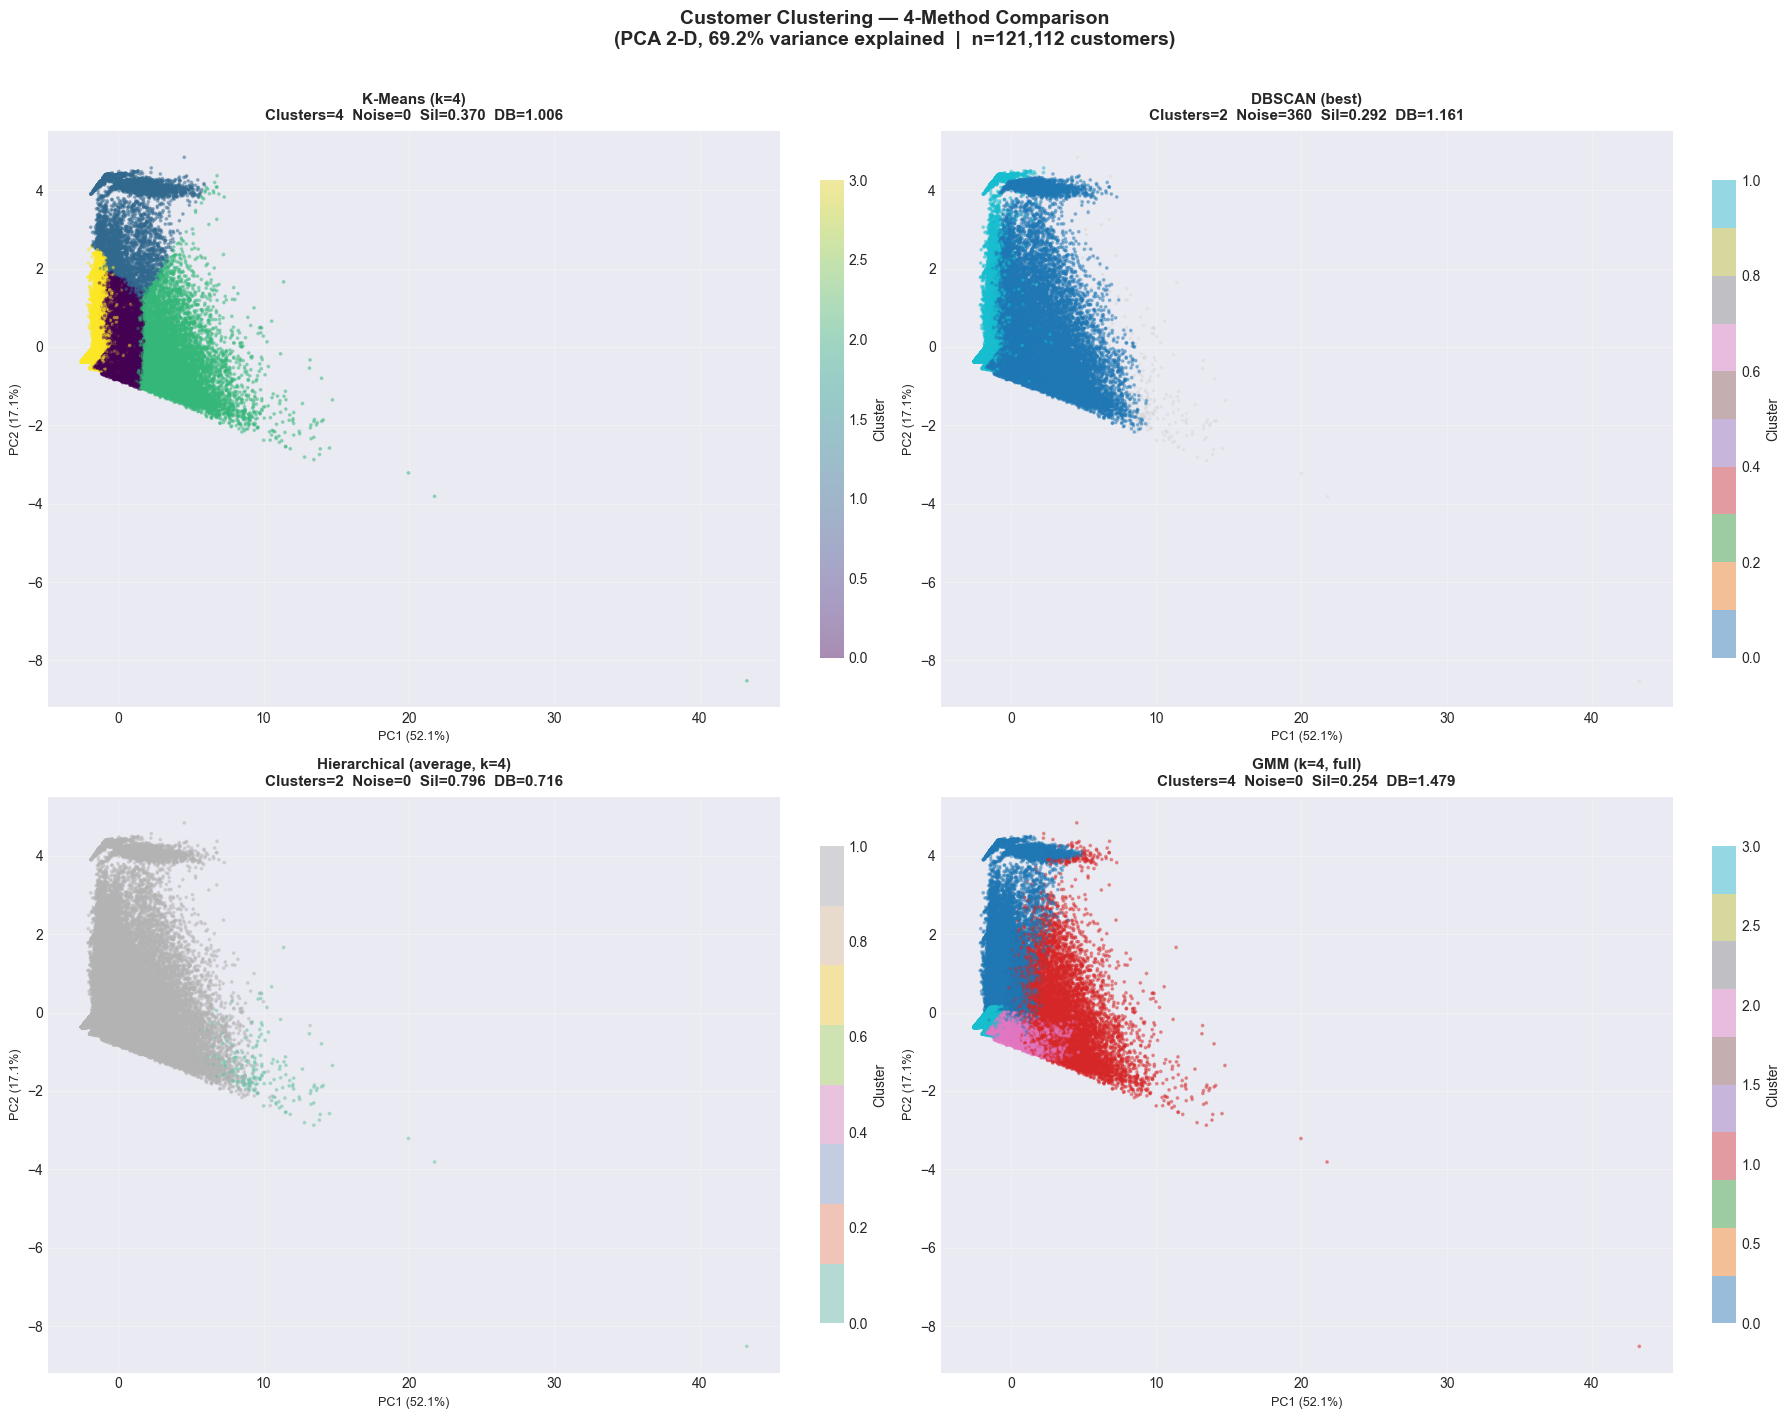

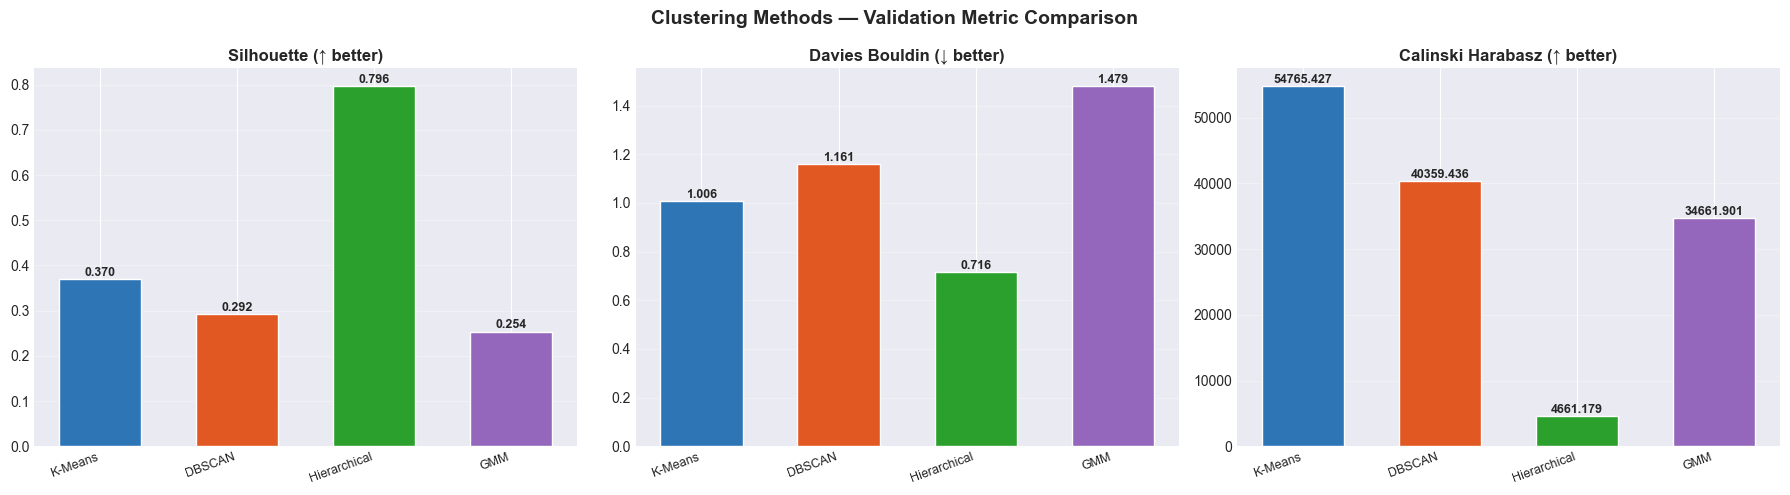

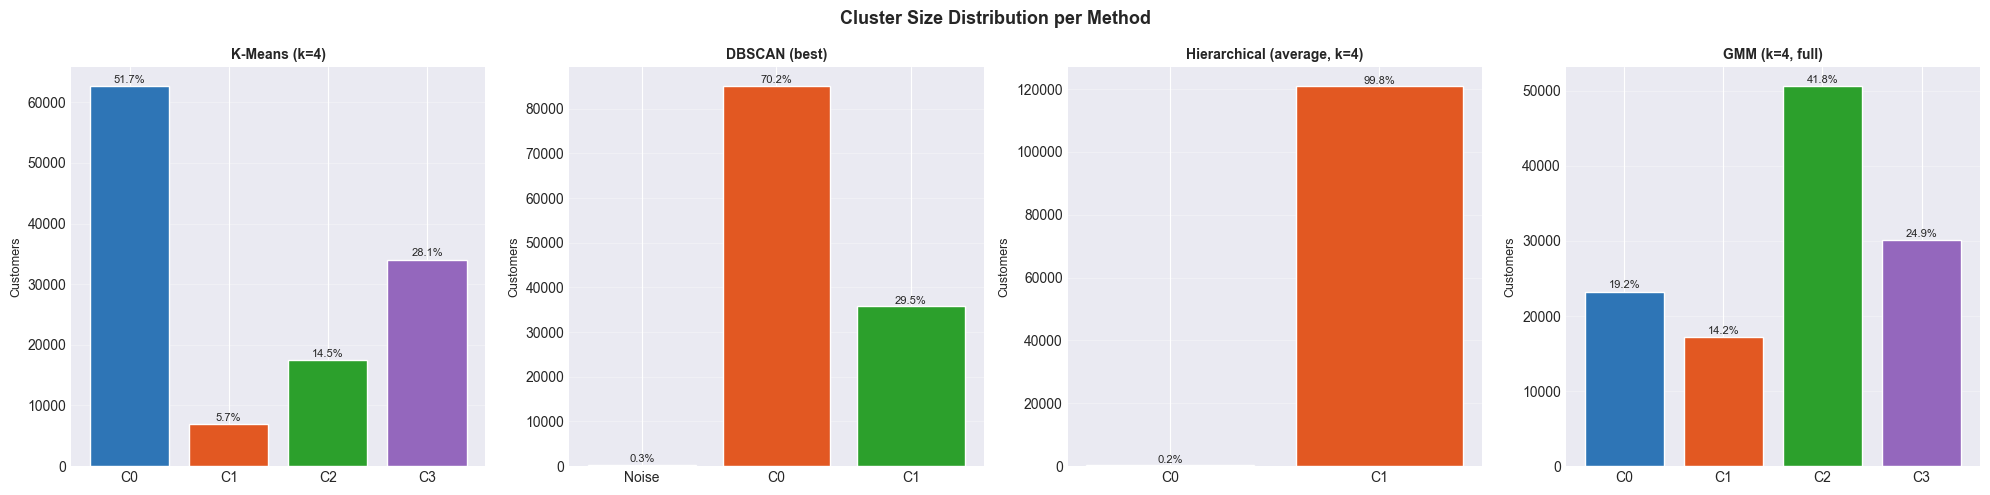

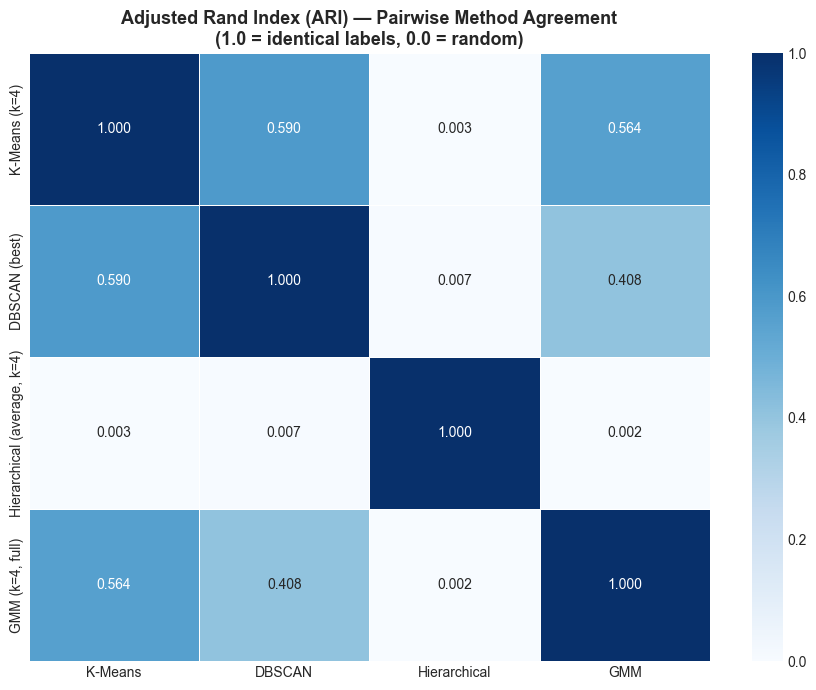


✓ All comparison plots saved.

Files generated:
  • dbscan_kdist.png
  • dbscan_pca.png
  • hierarchical_dendrograms.png
  • hierarchical_silhouette_k.png
  • hierarchical_pca.png
  • gmm_bic_aic.png
  • gmm_pca.png
  • gmm_weights.png
  • clustering_comparison_pca.png
  • clustering_metrics_comparison.png
  • cluster_size_comparison.png
  • clustering_ari_heatmap.png


In [60]:
# ============================================================================
# FULL COMPARISON — K-Means vs DBSCAN vs Hierarchical vs GMM
# ============================================================================

# ---- 0) Utility: safe silhouette (skip if <2 clusters after noise removal) --
def safe_sil(X, lbl, sample=5_000):
    mask = lbl != -1
    u = np.unique(lbl[mask])
    if len(u) < 2: return np.nan
    return silhouette_score(X[mask], lbl[mask], sample_size=min(5_000, mask.sum()),
                            random_state=42)

def safe_db(X, lbl):
    mask = lbl != -1
    u = np.unique(lbl[mask])
    if len(u) < 2: return np.nan
    return davies_bouldin_score(X[mask], lbl[mask])

def safe_ch(X, lbl):
    mask = lbl != -1
    u = np.unique(lbl[mask])
    if len(u) < 2: return np.nan
    return calinski_harabasz_score(X[mask], lbl[mask])

# ---- 1) Metric table --------------------------------------------------------
methods = {
    "K-Means (k=4)"          : labels_kmeans,
    "DBSCAN (best)"           : labels_dbscan,
    f"Hierarchical ({best_linkage}, k=4)" : labels_hier,
    f"GMM (k=4, {best_cov})"  : labels_gmm,
}

rows = []
for name, lbl in methods.items():
    n_clust  = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise    = (lbl == -1).sum()
    sil      = safe_sil(X, lbl)
    db       = safe_db(X, lbl)
    ch       = safe_ch(X, lbl)
    rows.append(dict(Method=name, Clusters=n_clust,
                     Noise=noise, Silhouette=sil,
                     Davies_Bouldin=db, Calinski_Harabasz=ch))

df_compare = pd.DataFrame(rows).set_index("Method")
print("=" * 90)
print("CLUSTERING COMPARISON TABLE")
print("=" * 90)
print(df_compare.round(3).to_string())
print()
print("Notes:")
print("  Silhouette        → higher is better  (range -1 to 1)")
print("  Davies-Bouldin    → lower  is better  (≥ 0)")
print("  Calinski-Harabasz → higher is better  (> 0, unbounded)")

# ---- 2) Side-by-side PCA plots (2×2 grid) -----------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
titles = list(methods.keys())
cmaps  = ["viridis", "tab10", "Set2", "tab10"]

for ax, (name, lbl), cmap in zip(axes, methods.items(), cmaps):
    mask_plot = lbl != -1
    c_vals    = lbl[mask_plot]
    ax.scatter(X_pca[~mask_plot, 0], X_pca[~mask_plot, 1],
               c="lightgrey", s=2, alpha=0.3, rasterized=True, label="noise")
    sc = ax.scatter(X_pca[mask_plot, 0], X_pca[mask_plot, 1],
                    c=c_vals, cmap=cmap, s=3, alpha=0.4, rasterized=True)
    sil_val = df_compare.loc[name, "Silhouette"]
    db_val  = df_compare.loc[name, "Davies_Bouldin"]
    n_c     = df_compare.loc[name, "Clusters"]
    noise_n = df_compare.loc[name, "Noise"]
    ax.set_title(
        f"{name}\nClusters={n_c}  Noise={noise_n}  Sil={sil_val:.3f}  DB={db_val:.3f}",
        fontsize=11, fontweight="bold", pad=8
    )
    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})", fontsize=9)
    ax.grid(alpha=0.25)
    plt.colorbar(sc, ax=ax, label="Cluster", fraction=0.03)

plt.suptitle(
    f"Customer Clustering — 4-Method Comparison\n"
    f"(PCA 2-D, {var_explained:.1%} variance explained  |  n={len(X):,} customers)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("clustering_comparison_pca.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

# ---- 3) Metric radar / bar comparison ---------------------------------------
metrics_plot = ["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]
df_bar = df_compare[metrics_plot].copy()

# Normalise each metric 0–1 (Silhouette & CH: higher=better → keep raw rank)
# For DB: invert so that higher bar = better
df_norm = df_bar.copy()
df_norm["Davies_Bouldin"] = 1 / (1 + df_bar["Davies_Bouldin"])   # invert
df_norm["Silhouette"]     = (df_bar["Silhouette"] - df_bar["Silhouette"].min()) /                              (df_bar["Silhouette"].max() - df_bar["Silhouette"].min() + 1e-9)
df_norm["Calinski_Harabasz"] = (df_bar["Calinski_Harabasz"] - df_bar["Calinski_Harabasz"].min()) /                                 (df_bar["Calinski_Harabasz"].max() - df_bar["Calinski_Harabasz"].min() + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = ["#2E75B6", "#E25822", "#2CA02C", "#9467BD"]

for ax, metric in zip(axes, metrics_plot):
    vals_m = df_bar[metric].values
    bars = ax.bar(range(len(df_bar)), vals_m, color=bar_colors, edgecolor="white", width=0.6)
    ax.set_xticks(range(len(df_bar)))
    ax.set_xticklabels([m.split(" ")[0] for m in df_bar.index], rotation=20, ha="right", fontsize=9)
    arrow = "↑ better" if metric != "Davies_Bouldin" else "↓ better"
    ax.set_title(f"{metric.replace('_', ' ')} ({arrow})", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")
    for bar, val in zip(bars, vals_m):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Clustering Methods — Validation Metric Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("clustering_metrics_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

# ---- 4) Cluster-size distribution comparison --------------------------------
fig, axes = plt.subplots(1, len(methods), figsize=(20, 5))
for ax, (name, lbl) in zip(axes, methods.items()):
    vals, cnts = np.unique(lbl, return_counts=True)
    clr = ["lightgrey" if v == -1 else bar_colors[i % len(bar_colors)]
           for i, v in enumerate(vals)]
    bars = ax.bar([f"C{v}" if v != -1 else "Noise" for v in vals],
                  cnts, color=clr, edgecolor="white")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_ylabel("Customers", fontsize=9)
    ax.grid(alpha=0.3, axis="y")
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f"{cnt/len(lbl)*100:.1f}%", ha="center", va="bottom", fontsize=8)

plt.suptitle("Cluster Size Distribution per Method", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cluster_size_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

# ---- 5) Agreement heatmap (ARI matrix) -------------------------------------
method_names = list(methods.keys())
n_m = len(method_names)
ari_matrix = np.zeros((n_m, n_m))

for i, (n1, l1) in enumerate(methods.items()):
    for j, (n2, l2) in enumerate(methods.items()):
        ari_matrix[i, j] = adjusted_rand_score(l1, l2)

fig, ax = plt.subplots(figsize=(9, 7))
short_names = [n.split(" ")[0] for n in method_names]
sns.heatmap(ari_matrix, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=short_names, yticklabels=method_names,
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Adjusted Rand Index (ARI) — Pairwise Method Agreement\n"
             "(1.0 = identical labels, 0.0 = random)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("clustering_ari_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

print("\n✓ All comparison plots saved.")
print("\nFiles generated:")
for f in ["dbscan_kdist.png", "dbscan_pca.png",
          "hierarchical_dendrograms.png", "hierarchical_silhouette_k.png",
          "hierarchical_pca.png", "gmm_bic_aic.png", "gmm_pca.png",
          "gmm_weights.png", "clustering_comparison_pca.png",
          "clustering_metrics_comparison.png", "cluster_size_comparison.png",
          "clustering_ari_heatmap.png"]:
    print(f"  • {f}")


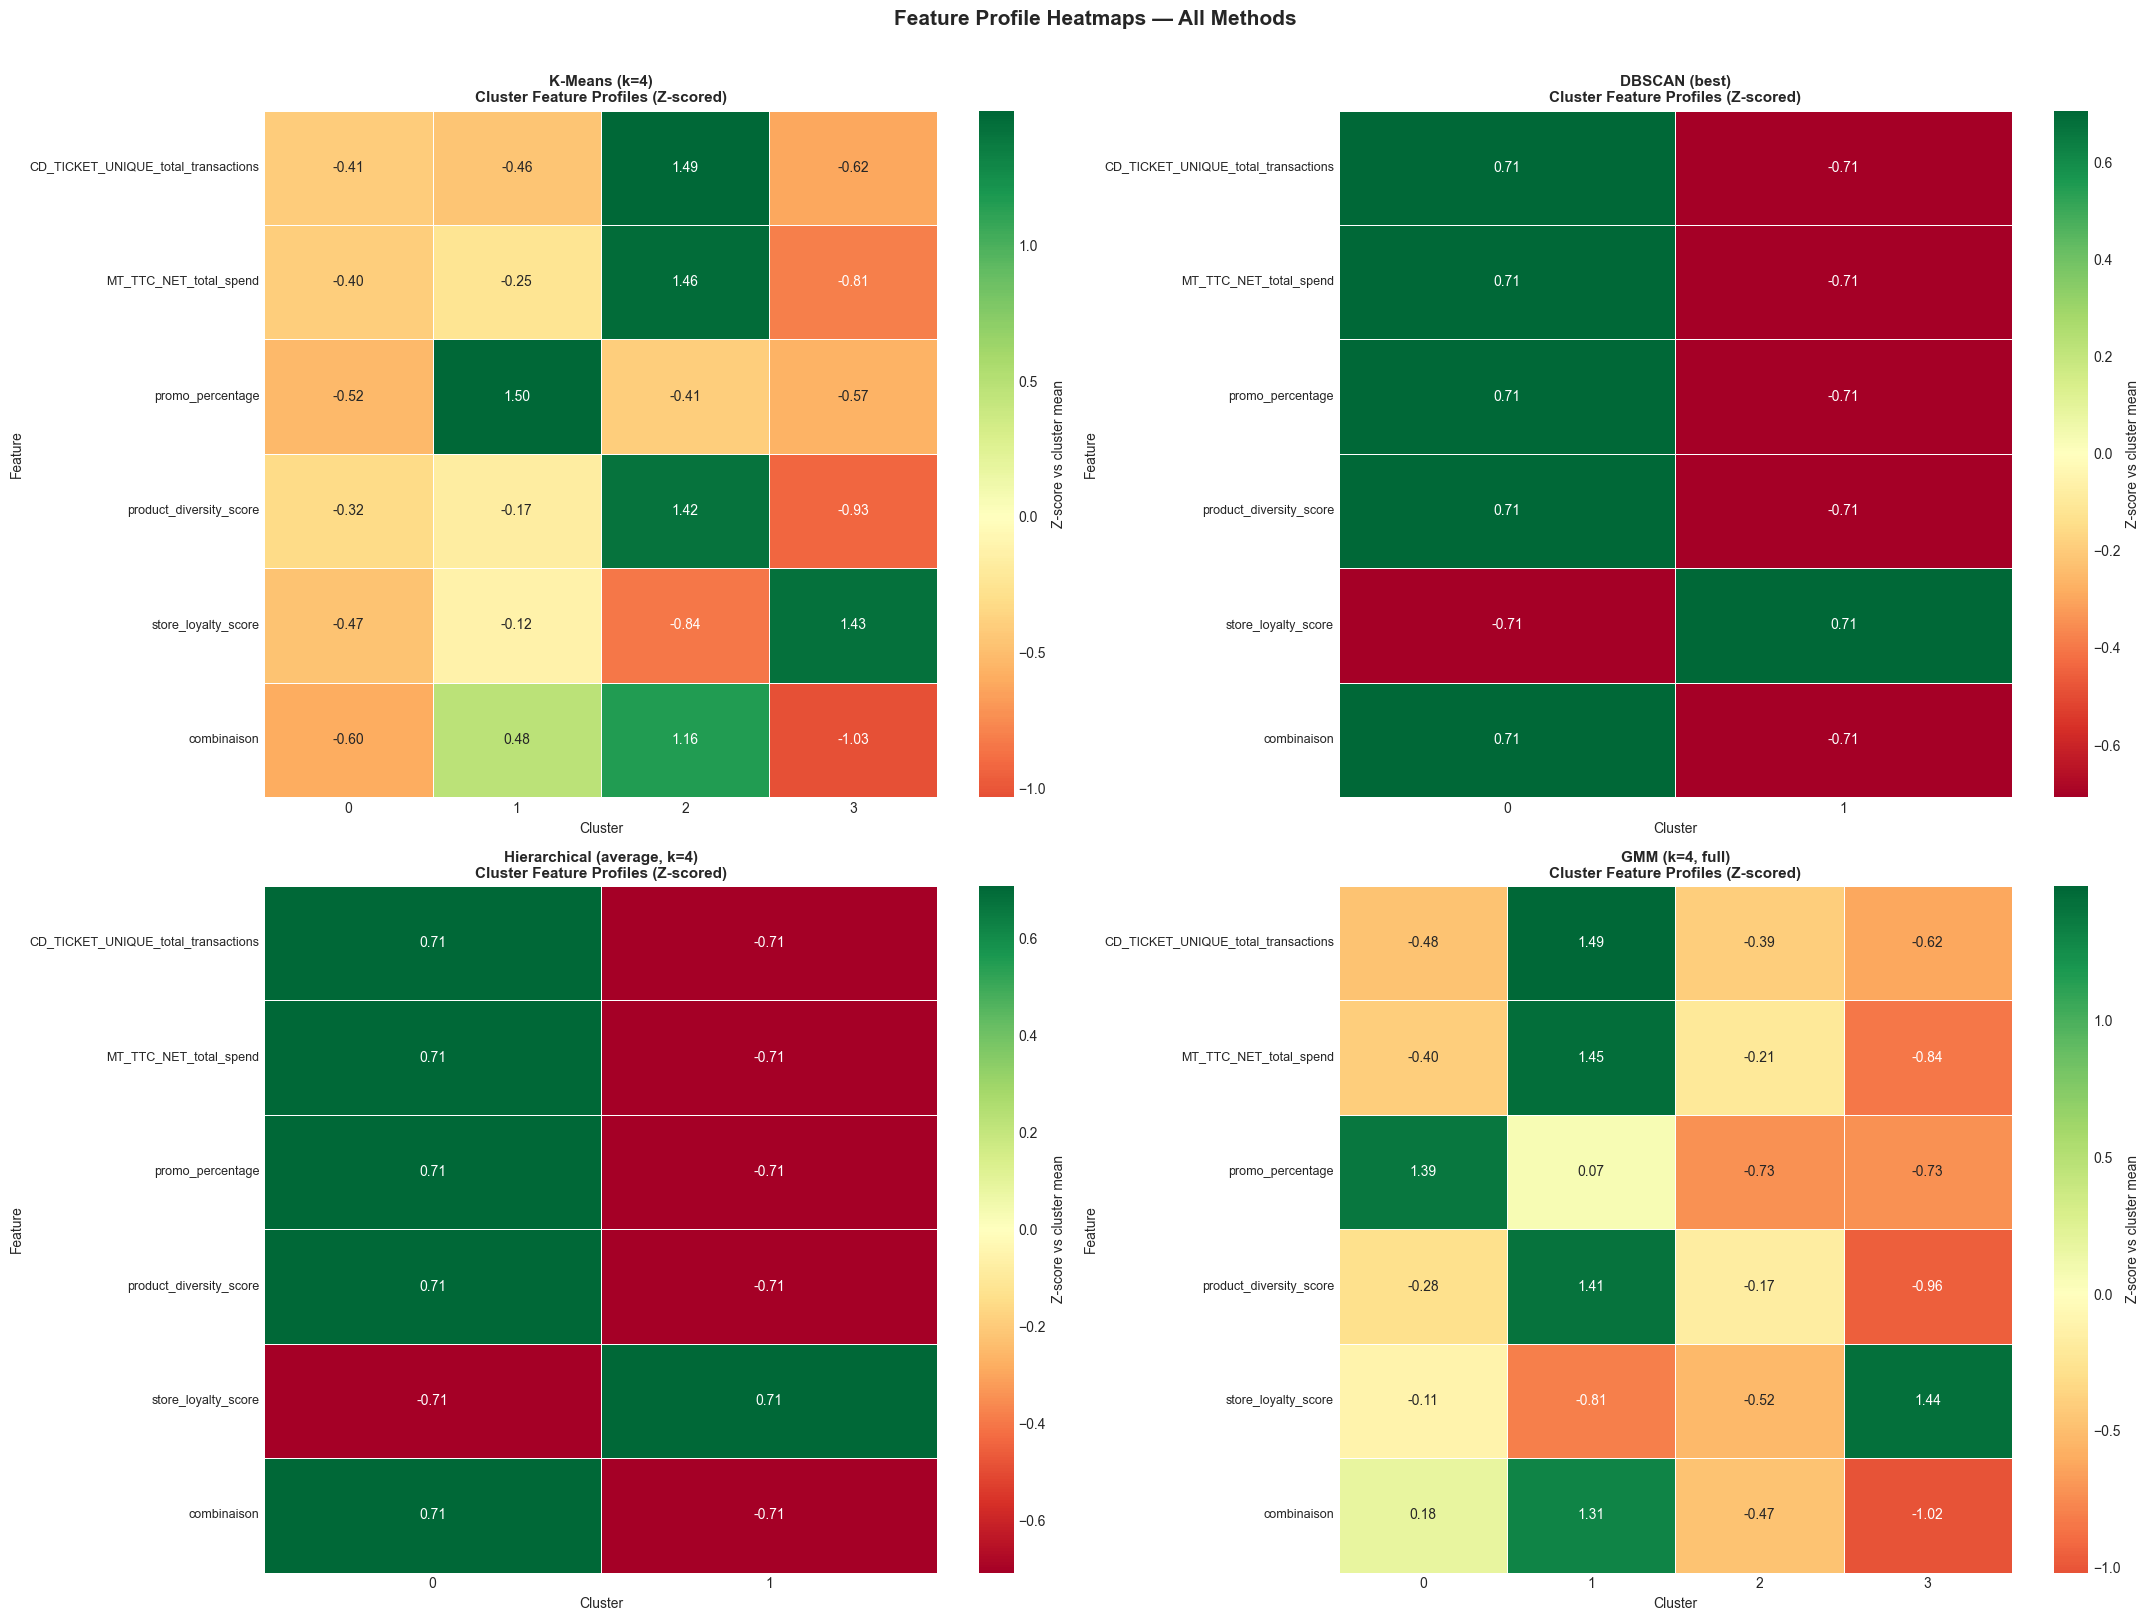


K-Means mean profiles (raw):
         CD_TICKET_UNIQUE_total_transactions  MT_TTC_NET_total_spend  promo_percentage  product_diversity_score  store_loyalty_score  combinaison
Cluster                                                                                                                                          
0                                      1.280                  32.150             4.430                   19.230                0.430       -0.080
1                                      1.240                  38.650            86.750                   22.950                0.530        0.370
2                                      2.660                 111.290             9.190                   63.370                0.310        0.650
3                                      1.130                  14.880             2.670                    3.510                1.000       -0.260

GMM mean profiles (raw):
         CD_TICKET_UNIQUE_total_transactions  MT_TTC_NET_total_spend

In [61]:
# ============================================================================
# SEGMENT FEATURE PROFILES — COMPARISON ACROSS METHODS
# ============================================================================
# Heatmap of mean feature values (standardised) per cluster for each method.
# Helps assess whether methods discover similar behavioural groups.
# ============================================================================

profile_features = CLUSTERING_FEATURES   # 7 original features

def cluster_profile(X_raw, lbl, features, exclude_noise=True):
    df_p = pd.DataFrame(X_raw, columns=features)
    df_p["Cluster"] = lbl
    if exclude_noise:
        df_p = df_p[df_p["Cluster"] != -1]
    profile = df_p.groupby("Cluster")[features].mean()
    # Z-score each feature across clusters for visual comparison
    profile_z = (profile - profile.mean()) / (profile.std() + 1e-9)
    return profile, profile_z

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.flatten()

X_raw = scaler_shared.inverse_transform(X)   # back to original scale for profiles

for ax, (name, lbl) in zip(axes, methods.items()):
    _, pz = cluster_profile(X_raw, lbl, profile_features)
    sns.heatmap(pz.T, ax=ax, cmap="RdYlGn", center=0,
                annot=True, fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Z-score vs cluster mean"})
    ax.set_title(f"{name}\nCluster Feature Profiles (Z-scored)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster", fontsize=10)
    ax.set_ylabel("Feature", fontsize=10)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.suptitle("Feature Profile Heatmaps — All Methods",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("clustering_profile_heatmaps.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

# ---- Summary table of raw profiles (K-Means reference) ---------------------
profile_km, _ = cluster_profile(X_raw, labels_kmeans, profile_features)
profile_gm, _ = cluster_profile(X_raw, labels_gmm,    profile_features)
profile_hi, _ = cluster_profile(X_raw, labels_hier,   profile_features)

print("\nK-Means mean profiles (raw):")
print(profile_km.round(2).to_string())
print("\nGMM mean profiles (raw):")
print(profile_gm.round(2).to_string())
print("\nHierarchical mean profiles (raw):")
print(profile_hi.round(2).to_string())

print("\n✓ Profile heatmaps saved → clustering_profile_heatmaps.png")
print("\n" + "="*80)
print("CLUSTERING COMPARISON COMPLETE")
print("="*80)
print(df_compare.round(3).to_string())
